# 🛩️ NASA Turbofan Jet Engine - Data Validation & EDA

**Dataset:** C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)  
**Goal:** Predict Remaining Useful Life (RUL) of turbofan jet engines  

| Dataset | Train Engines | Test Engines | Conditions | Fault Modes |
|---------|--------------|-------------|------------|-------------|
| FD001   | 100          | 100         | 1 (Sea Level) | 1 (HPC Degradation) |
| FD002   | 260          | 259         | 6          | 1 (HPC Degradation) |
| FD003   | 100          | 100         | 1 (Sea Level) | 2 (HPC + Fan) |
| FD004   | 248          | 249         | 6          | 2 (HPC + Fan) |

**Columns (26):** unit_id, cycle, op_setting_1-3, sensor_1-21

## 1. Setup & Load Data

In [582]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Color palette
COLORS = sns.color_palette('husl', 8)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [583]:
# Define column names
col_names = ['unit_id', 'cycle'] + \
            [f'op_setting_{i}' for i in range(1, 4)] + \
            [f'sensor_{i}' for i in range(1, 22)]

DATA_DIR = 'CMaps'

# Load all datasets
datasets = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    # Resolve dataset folder robustly (handles different notebook working directories)
    candidate_dirs = [
        DATA_DIR,
        os.path.join('.', DATA_DIR),
        os.path.join('..', DATA_DIR),
        os.getcwd(),
        os.path.join(os.getcwd(), DATA_DIR),
    ]

    loaded = False
    checked_paths = []
    for base_dir in dict.fromkeys(candidate_dirs):  # remove duplicates, keep order
        train_path = os.path.join(base_dir, f'train_{fd}.txt')
        test_path  = os.path.join(base_dir, f'test_{fd}.txt')
        rul_path   = os.path.join(base_dir, f'RUL_{fd}.txt')
        checked_paths.append((train_path, test_path, rul_path))

        if all(os.path.isfile(p) for p in [train_path, test_path, rul_path]):
            datasets[fd] = {
                'train': pd.read_csv(train_path, sep=r'\s+', header=None, names=col_names),
                'test':  pd.read_csv(test_path,  sep=r'\s+', header=None, names=col_names),
                'rul':   pd.read_csv(rul_path,   sep=r'\s+', header=None, names=['RUL'])
            }
            loaded = True
            break

    if not loaded:
        raise FileNotFoundError(
            f"Could not find files for {fd}. Current working directory: {os.getcwd()}\n"
            f"Checked:\n" + "\n".join([f"  - {t}\n    {te}\n    {r}" for t, te, r in checked_paths])
        )

print('All 4 sub-datasets (train, test, RUL for each) have been loaded.')
print(f'Columns: {col_names}')

All 4 sub-datasets (train, test, RUL for each) have been loaded.
Columns: ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


## 2. Data Validation

### 2.1 Shape & Basic Info

In [584]:
# Overview table
overview_rows = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = datasets[fd]
    overview_rows.append({
        'Dataset': fd,
        'Train Rows': d['train'].shape[0],
        'Train Cols': d['train'].shape[1],
        'Train Engines': d['train']['unit_id'].nunique(),
        'Test Rows': d['test'].shape[0],
        'Test Cols': d['test'].shape[1],
        'Test Engines': d['test']['unit_id'].nunique(),
        'RUL Count': len(d['rul']),
    })

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

# Validate: RUL count should match test engines
for _, row in overview_df.iterrows():
    match = 'OK' if row['Test Engines'] == row['RUL Count'] else 'Mismatch'
    print(f"{row['Dataset']}: Test Engines ({row['Test Engines']}) vs RUL Count ({row['RUL Count']}) -> {match}")

,Dataset,Train Rows,Train Cols,Train Engines,Test Rows,Test Cols,Test Engines,RUL Count
0,FD001,20631,26,100,13096,26,100,100
1,FD002,53759,26,260,33991,26,259,259
2,FD003,24720,26,100,16596,26,100,100
3,FD004,61249,26,249,41214,26,248,248


FD001: Test Engines (100) vs RUL Count (100) -> OK
FD002: Test Engines (259) vs RUL Count (259) -> OK
FD003: Test Engines (100) vs RUL Count (100) -> OK
FD004: Test Engines (248) vs RUL Count (248) -> OK


### 2.2 Missing Values Check

In [585]:
print('='*60)
print('MISSING VALUES CHECK')
print('='*60)

has_missing = False
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    for split in ['train', 'test']:
        df = datasets[fd][split]
        missing_total = df.isnull().sum().sum()
        if missing_total > 0:
            has_missing = True
            print(f'\n[Found] {fd} {split}: {missing_total} missing values')
            print(df.isnull().sum()[df.isnull().sum() > 0])
        else:
            print(f'[OK] {fd} {split}: No missing values')

if not has_missing:
    print('\nValidation complete: No missing values in any dataset.')

MISSING VALUES CHECK
[OK] FD001 train: No missing values
[OK] FD001 test: No missing values
[OK] FD002 train: No missing values
[OK] FD002 test: No missing values
[OK] FD003 train: No missing values
[OK] FD003 test: No missing values
[OK] FD004 train: No missing values
[OK] FD004 test: No missing values

Validation complete: No missing values in any dataset.


### 2.3 Duplicate Rows Check

In [586]:
print('='*60)
print('DUPLICATE ROWS CHECK')
print('='*60)

for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    for split in ['train', 'test']:
        df = datasets[fd][split]
        n_dup = df.duplicated().sum()
        # Also check for duplicate (unit_id, cycle) pairs
        n_dup_keys = df.duplicated(subset=['unit_id', 'cycle']).sum()
        status = 'OK' if n_dup == 0 and n_dup_keys == 0 else 'Warning'
        print(f'[{status}] {fd} {split}: {n_dup} duplicate rows, {n_dup_keys} duplicate (unit_id, cycle) pairs')

DUPLICATE ROWS CHECK
[OK] FD001 train: 0 duplicate rows, 0 duplicate (unit_id, cycle) pairs
[OK] FD001 test: 0 duplicate rows, 0 duplicate (unit_id, cycle) pairs
[OK] FD002 train: 0 duplicate rows, 0 duplicate (unit_id, cycle) pairs
[OK] FD002 test: 0 duplicate rows, 0 duplicate (unit_id, cycle) pairs
[OK] FD003 train: 0 duplicate rows, 0 duplicate (unit_id, cycle) pairs
[OK] FD003 test: 0 duplicate rows, 0 duplicate (unit_id, cycle) pairs
[OK] FD004 train: 0 duplicate rows, 0 duplicate (unit_id, cycle) pairs
[OK] FD004 test: 0 duplicate rows, 0 duplicate (unit_id, cycle) pairs


### 2.4 Data Types & Value Ranges

In [587]:
# Show data types for FD001 train (representative)
print('Data Types (FD001 train):')
print(datasets['FD001']['train'].dtypes)
print()

# Check for non-numeric or unexpected dtypes
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    df = datasets[fd]['train']
    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric:
        print(f'[Error] {fd}: Non-numeric columns found: {non_numeric}')
    else:
        print(f'[OK] {fd}: All columns are numeric')

Data Types (FD001 train):
unit_id           int64
cycle             int64
op_setting_1    float64
op_setting_2    float64
op_setting_3    float64
sensor_1        float64
sensor_2        float64
sensor_3        float64
sensor_4        float64
sensor_5        float64
sensor_6        float64
sensor_7        float64
sensor_8        float64
sensor_9        float64
sensor_10       float64
sensor_11       float64
sensor_12       float64
sensor_13       float64
sensor_14       float64
sensor_15       float64
sensor_16       float64
sensor_17         int64
sensor_18         int64
sensor_19       float64
sensor_20       float64
sensor_21       float64
dtype: object

[OK] FD001: All columns are numeric
[OK] FD002: All columns are numeric
[OK] FD003: All columns are numeric
[OK] FD004: All columns are numeric


In [588]:
# Descriptive statistics for FD001 train
print('Descriptive Statistics - FD001 Train')
datasets['FD001']['train'].describe().T.round(3)

Descriptive Statistics - FD001 Train


,count,mean,std,min,25%,50%,75%,max
unit_id,20631.0,51.507,29.228,1.000,26.000,52.000,77.000,100.000
cycle,20631.0,108.808,68.881,1.000,52.000,104.000,156.000,362.000
op_setting_1,20631.0,-0.000,0.002,-0.009,-0.002,0.000,0.002,0.009
op_setting_2,20631.0,0.000,0.000,-0.001,-0.000,0.000,0.000,0.001
op_setting_3,20631.0,100.000,0.000,100.000,100.000,100.000,100.000,100.000
sensor_1,20631.0,518.670,0.000,518.670,518.670,518.670,518.670,518.670
sensor_2,20631.0,642.681,0.500,641.210,642.325,642.640,643.000,644.530
sensor_3,20631.0,1590.523,6.131,1571.040,1586.260,1590.100,1594.380,1616.910
sensor_4,20631.0,1408.934,9.001,1382.250,1402.360,1408.040,1414.555,1441.490
sensor_5,20631.0,14.620,0.000,14.620,14.620,14.620,14.620,14.620


### 2.5 Constant / Near-Constant Sensors

In [589]:
# Identify sensors with zero or near-zero variance
print('='*60)
print('CONSTANT / NEAR-CONSTANT FEATURE DETECTION')
print('='*60)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
op_cols = [f'op_setting_{i}' for i in range(1, 4)]

for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    df = datasets[fd]['train']
    std_vals = df[sensor_cols + op_cols].std()
    constant_cols = std_vals[std_vals < 1e-6].index.tolist()
    near_constant = std_vals[(std_vals >= 1e-6) & (std_vals < 0.01)].index.tolist()
    
    print(f'\nAnalysis for {fd}:')
    if constant_cols:
        print(f'  - Constant (std ≈ 0): {constant_cols}')
    else:
        print(f'  - No constant columns found.')
    if near_constant:
        print(f'  - Near-constant (std < 0.01): {near_constant}')

CONSTANT / NEAR-CONSTANT FEATURE DETECTION

Analysis for FD001:
  - Constant (std ≈ 0): ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'op_setting_3']
  - Near-constant (std < 0.01): ['sensor_6', 'op_setting_1', 'op_setting_2']

Analysis for FD002:
  - No constant columns found.
  - Near-constant (std < 0.01): ['sensor_16']

Analysis for FD003:
  - Constant (std ≈ 0): ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19', 'op_setting_3']
  - Near-constant (std < 0.01): ['sensor_10', 'op_setting_1', 'op_setting_2']

Analysis for FD004:
  - No constant columns found.
  - Near-constant (std < 0.01): ['sensor_16']


### 2.6 Cycle Continuity Check

In [590]:
# Check if cycles are continuous (1, 2, 3, ..., N) for each engine
print('='*60)
print('CYCLE CONTINUITY CHECK')
print('='*60)

for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    for split in ['train', 'test']:
        df = datasets[fd][split]
        issues = []
        for uid in df['unit_id'].unique():
            engine_df = df[df['unit_id'] == uid]
            cycles = engine_df['cycle'].values
            expected = np.arange(1, len(cycles) + 1)
            if not np.array_equal(cycles, expected):
                issues.append(uid)
        
        if issues:
            print(f'[Warning] {fd} {split}: {len(issues)} engines with non-continuous cycles: {issues[:5]}...')
        else:
            print(f'[OK] {fd} {split}: All engines have continuous cycles (1, 2, ..., N)')

CYCLE CONTINUITY CHECK
[OK] FD001 train: All engines have continuous cycles (1, 2, ..., N)
[OK] FD001 test: All engines have continuous cycles (1, 2, ..., N)
[OK] FD002 train: All engines have continuous cycles (1, 2, ..., N)
[OK] FD002 test: All engines have continuous cycles (1, 2, ..., N)
[OK] FD003 train: All engines have continuous cycles (1, 2, ..., N)
[OK] FD003 test: All engines have continuous cycles (1, 2, ..., N)
[OK] FD004 train: All engines have continuous cycles (1, 2, ..., N)
[OK] FD004 test: All engines have continuous cycles (1, 2, ..., N)


---
## 3. Exploratory Data Analysis (EDA)

> We'll focus primarily on **FD001** for detailed analysis, then compare across all datasets.

### 3.1 Compute RUL for Training Data

In [591]:
def add_rul(df):
    """Add RUL column: for each engine, RUL = max_cycle - current_cycle"""
    max_cycles = df.groupby('unit_id')['cycle'].max().reset_index()
    max_cycles.columns = ['unit_id', 'max_cycle']
    df = df.merge(max_cycles, on='unit_id', how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop('max_cycle', axis=1, inplace=True)
    return df

# Add RUL to all training sets
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    datasets[fd]['train'] = add_rul(datasets[fd]['train'])

print('RUL column added to all training datasets.')
datasets['FD001']['train'][['unit_id', 'cycle', 'RUL']].head(10)

RUL column added to all training datasets.


,unit_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


### 3.2 Engine Lifetime Distribution

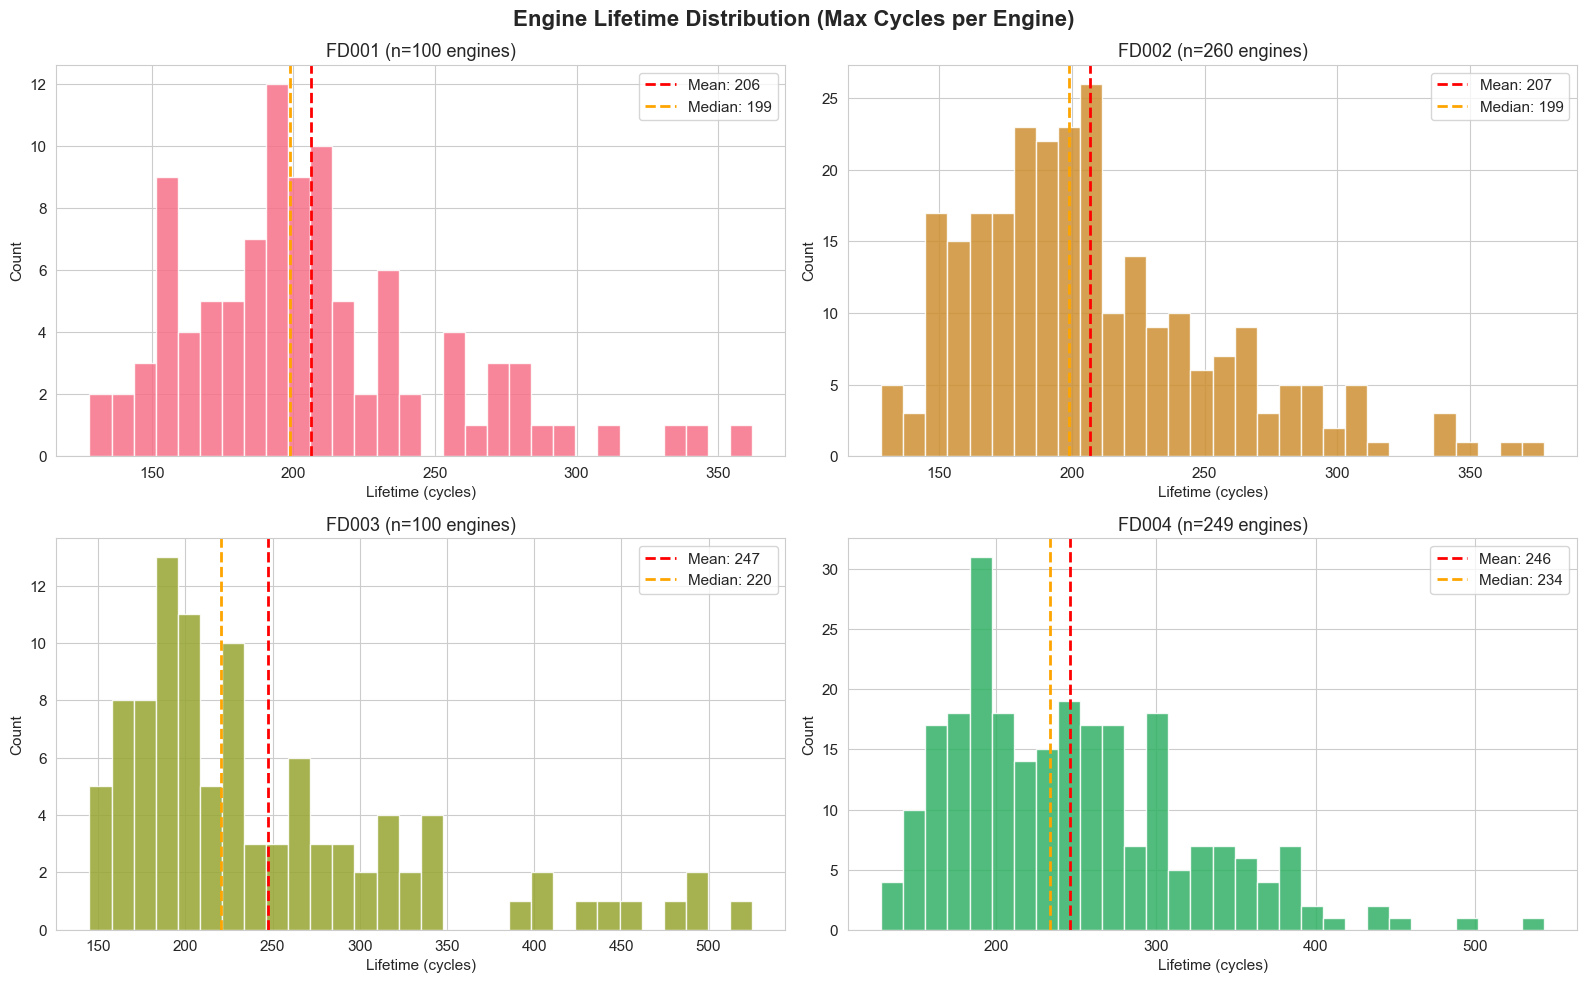

,Dataset,Min,Max,Mean,Median,Std
0,FD001,128,362,206.3,199.0,46.3
1,FD002,128,378,206.8,199.0,46.8
2,FD003,145,525,247.2,220.5,86.5
3,FD004,128,543,246.0,234.0,73.1


In [592]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Engine Lifetime Distribution (Max Cycles per Engine)', fontsize=16, fontweight='bold')

for idx, fd in enumerate(['FD001', 'FD002', 'FD003', 'FD004']):
    ax = axes[idx // 2][idx % 2]
    df = datasets[fd]['train']
    lifetimes = df.groupby('unit_id')['cycle'].max()
    
    ax.hist(lifetimes, bins=30, color=COLORS[idx], edgecolor='white', alpha=0.85)
    ax.axvline(lifetimes.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {lifetimes.mean():.0f}')
    ax.axvline(lifetimes.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {lifetimes.median():.0f}')
    ax.set_title(f'{fd} (n={len(lifetimes)} engines)', fontsize=13)
    ax.set_xlabel('Lifetime (cycles)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

# Summary stats
lifetime_stats = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    lifetimes = datasets[fd]['train'].groupby('unit_id')['cycle'].max()
    lifetime_stats.append({
        'Dataset': fd,
        'Min': lifetimes.min(),
        'Max': lifetimes.max(),
        'Mean': round(lifetimes.mean(), 1),
        'Median': lifetimes.median(),
        'Std': round(lifetimes.std(), 1)
    })
pd.DataFrame(lifetime_stats)

### 3.3 RUL Distribution (Training Ground Truth)

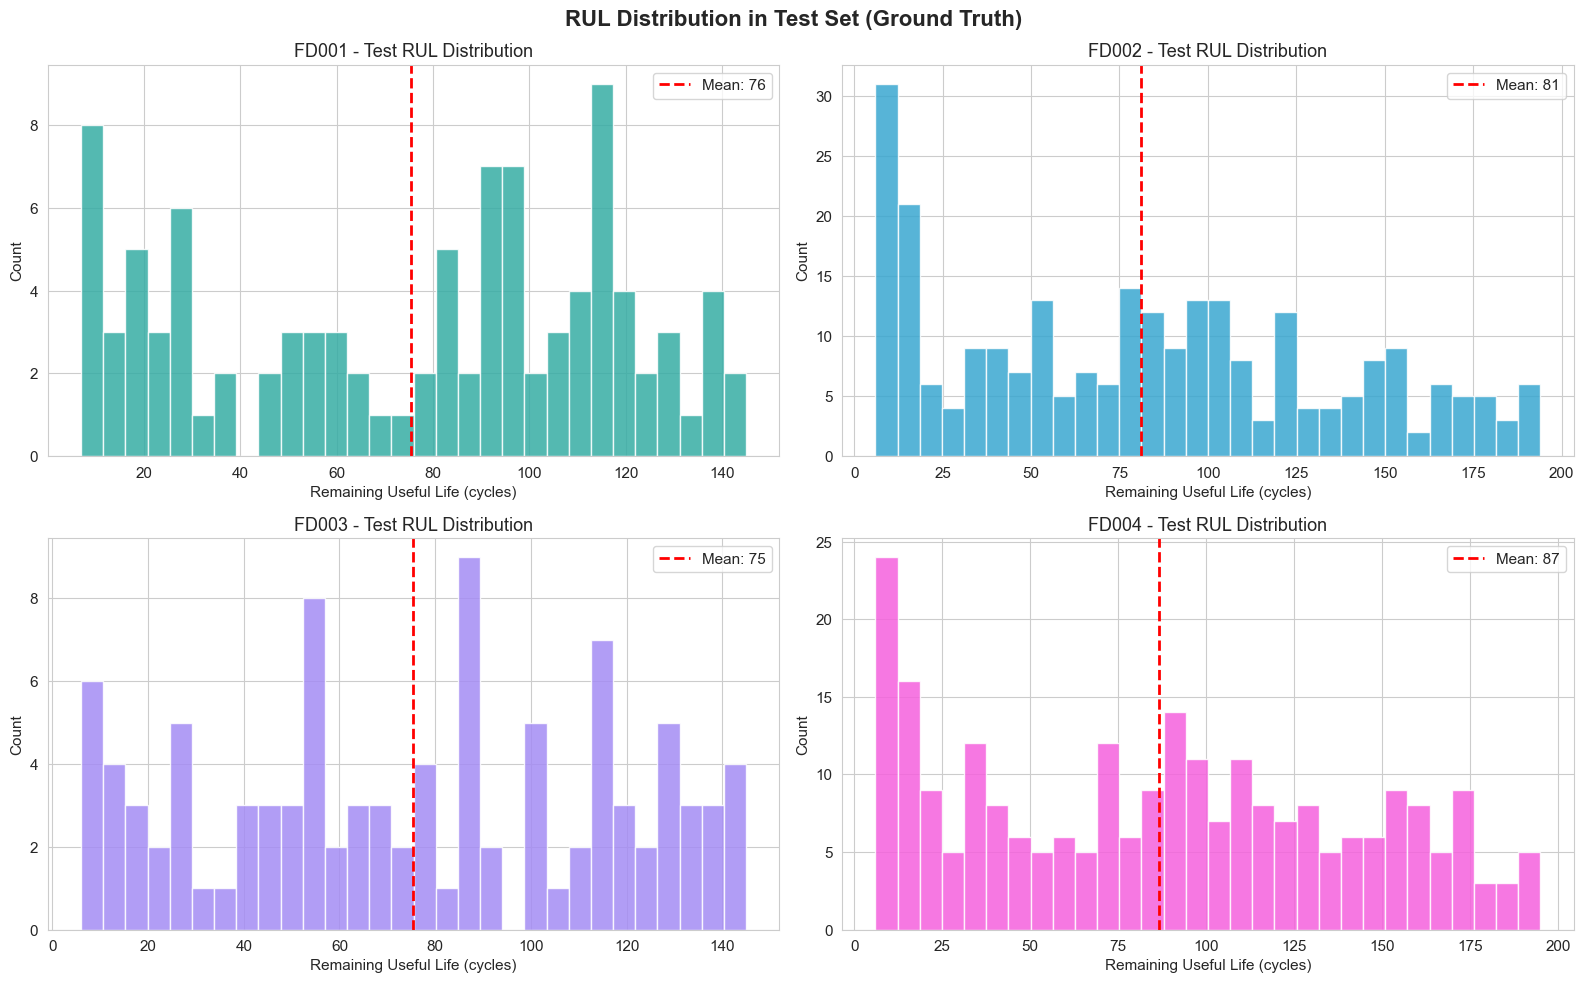

In [593]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('RUL Distribution in Test Set (Ground Truth)', fontsize=16, fontweight='bold')

for idx, fd in enumerate(['FD001', 'FD002', 'FD003', 'FD004']):
    ax = axes[idx // 2][idx % 2]
    rul = datasets[fd]['rul']['RUL']
    
    ax.hist(rul, bins=30, color=COLORS[idx+4], edgecolor='white', alpha=0.85)
    ax.axvline(rul.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rul.mean():.0f}')
    ax.set_title(f'{fd} - Test RUL Distribution', fontsize=13)
    ax.set_xlabel('Remaining Useful Life (cycles)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

### 3.4 Operational Settings Analysis

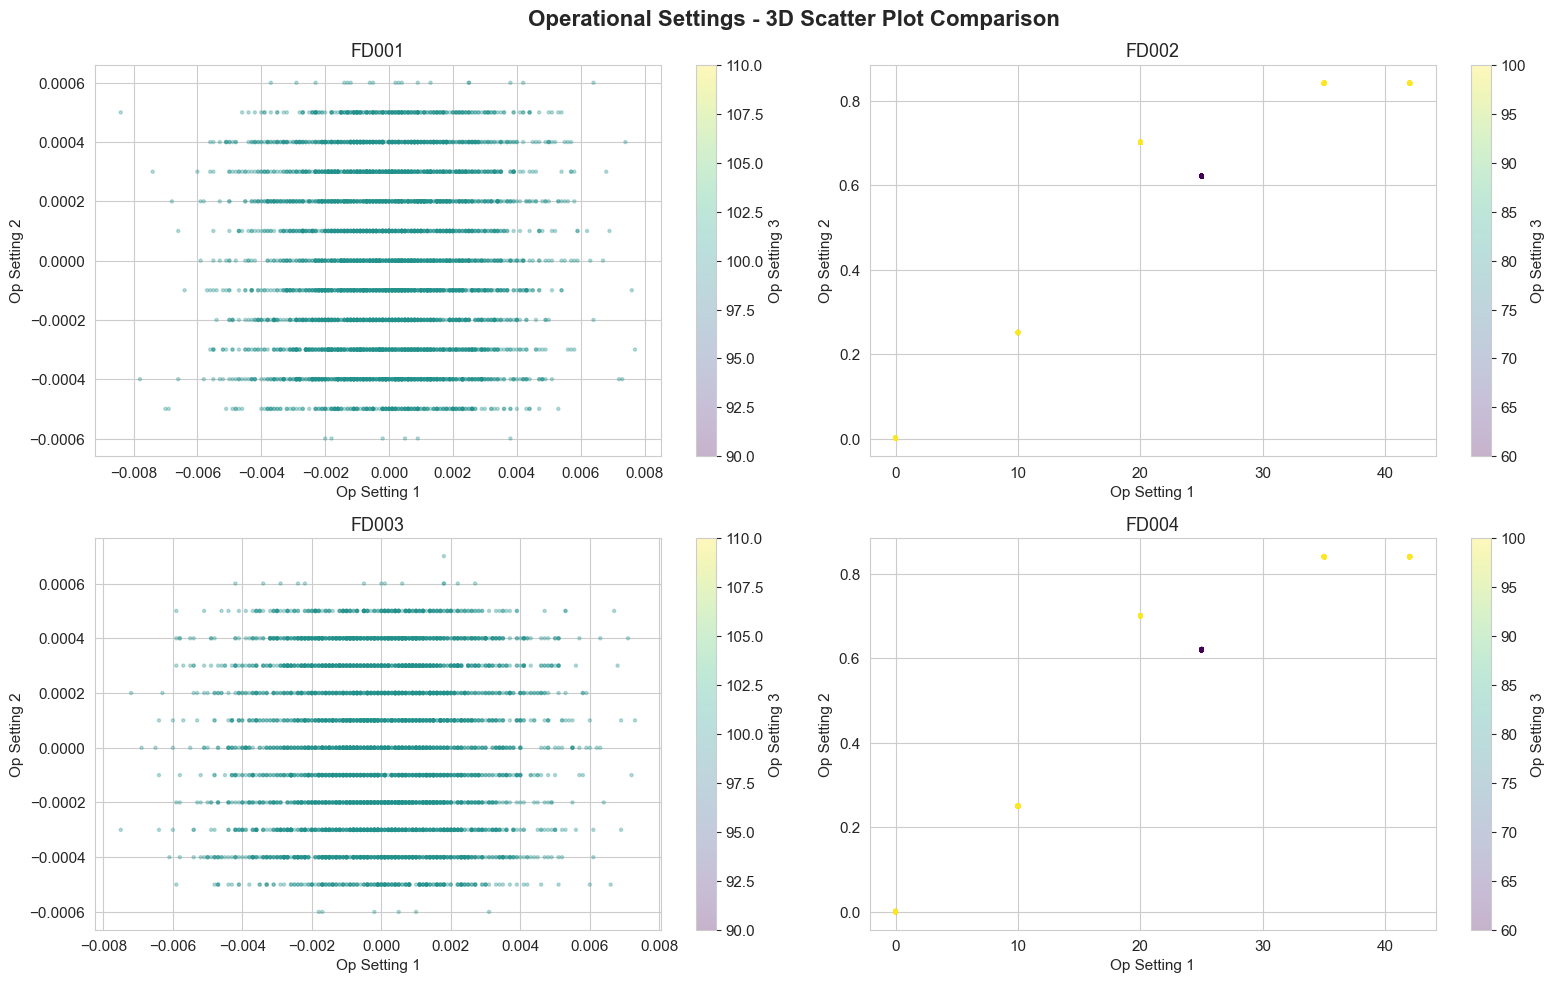

FD001: ~1423 unique operating condition combinations
FD002: ~9824 unique operating condition combinations
FD003: ~1479 unique operating condition combinations
FD004: ~10232 unique operating condition combinations


In [594]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Operational Settings - 3D Scatter Plot Comparison', fontsize=16, fontweight='bold')

for idx, fd in enumerate(['FD001', 'FD002', 'FD003', 'FD004']):
    ax = axes[idx // 2][idx % 2]
    df = datasets[fd]['train'].sample(min(5000, len(datasets[fd]['train'])), random_state=42)
    
    scatter = ax.scatter(df['op_setting_1'], df['op_setting_2'],
                        c=df['op_setting_3'], cmap='viridis', alpha=0.3, s=5)
    ax.set_xlabel('Op Setting 1')
    ax.set_ylabel('Op Setting 2')
    ax.set_title(f'{fd}', fontsize=13)
    plt.colorbar(scatter, ax=ax, label='Op Setting 3')

plt.tight_layout()
plt.show()

# Count unique operating conditions
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    df = datasets[fd]['train']
    n_conditions = df.groupby(['op_setting_1', 'op_setting_2', 'op_setting_3']).ngroups
    print(f'{fd}: ~{n_conditions} unique operating condition combinations')

### 3.5 Sensor Readings Overview (FD001)

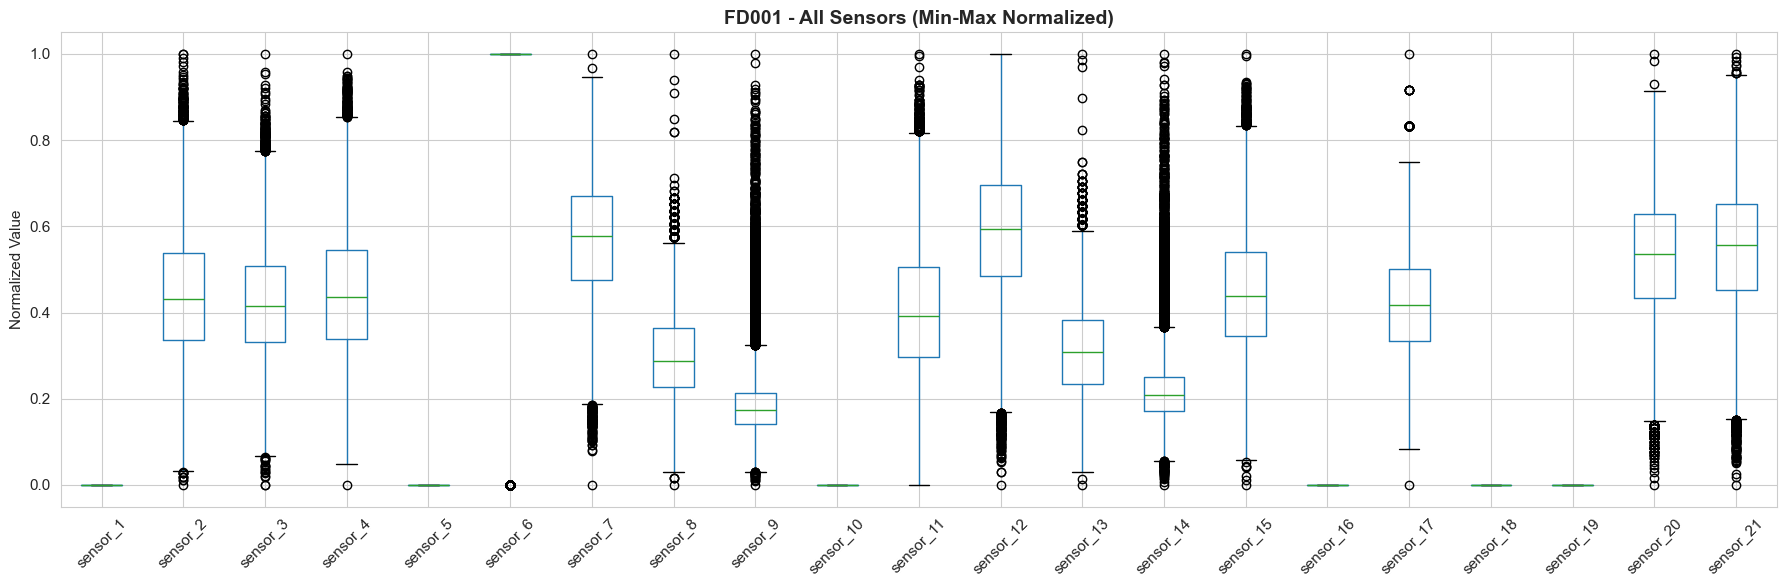

In [595]:
# Box plots of all sensors - normalized for comparison
df_fd1 = datasets['FD001']['train']

fig, ax = plt.subplots(figsize=(18, 6))
sensor_data = df_fd1[sensor_cols]
# Min-max normalize for visual comparison
sensor_norm = (sensor_data - sensor_data.min()) / (sensor_data.max() - sensor_data.min() + 1e-10)

sensor_norm.boxplot(ax=ax, rot=45)
ax.set_title('FD001 - All Sensors (Min-Max Normalized)', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Value')
plt.tight_layout()
plt.show()

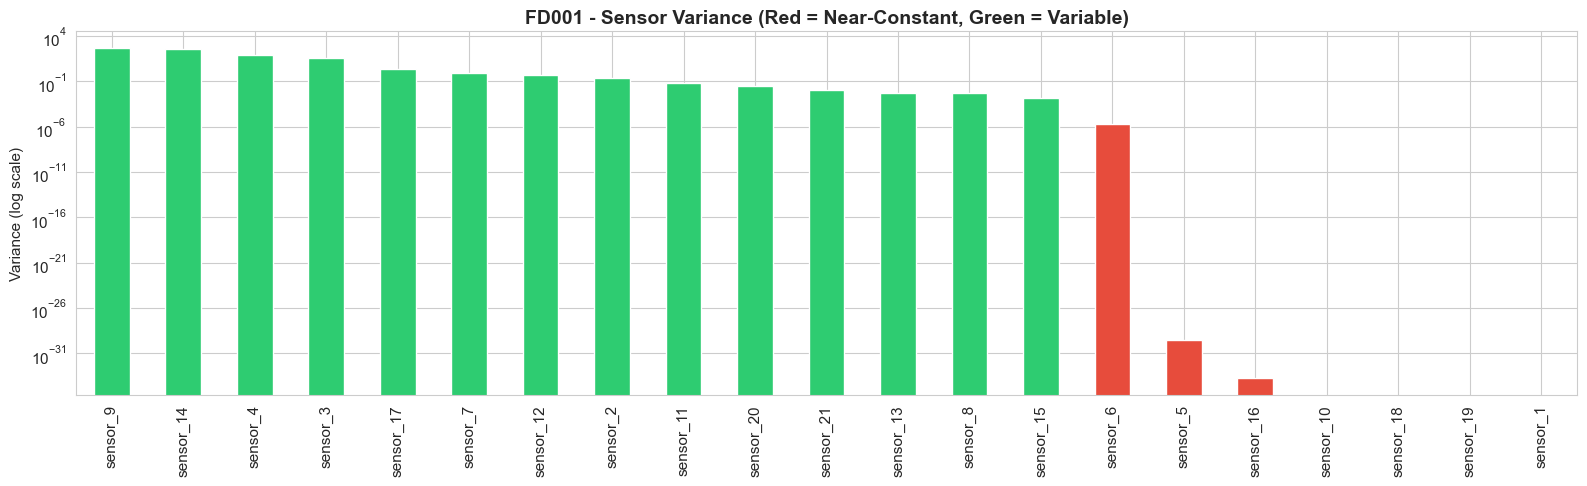


FD001 Useful sensors (14): ['sensor_9', 'sensor_14', 'sensor_4', 'sensor_3', 'sensor_17', 'sensor_7', 'sensor_12', 'sensor_2', 'sensor_11', 'sensor_20', 'sensor_21', 'sensor_13', 'sensor_8', 'sensor_15']
FD001 Constant/Near-constant sensors (7): ['sensor_6', 'sensor_5', 'sensor_16', 'sensor_10', 'sensor_18', 'sensor_19', 'sensor_1']


In [596]:
# Variance analysis to identify useful vs constant sensors
fig, ax = plt.subplots(figsize=(16, 5))

variances = df_fd1[sensor_cols].var().sort_values(ascending=False)
colors_bar = ['#e74c3c' if v < 0.001 else '#2ecc71' for v in variances]
variances.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title('FD001 - Sensor Variance (Red = Near-Constant, Green = Variable)', fontsize=14, fontweight='bold')
ax.set_ylabel('Variance (log scale)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

useful_sensors = variances[variances >= 0.001].index.tolist()
constant_sensors = variances[variances < 0.001].index.tolist()
print(f'\nFD001 Useful sensors ({len(useful_sensors)}): {useful_sensors}')
print(f'FD001 Constant/Near-constant sensors ({len(constant_sensors)}): {constant_sensors}')

### 3.6 Sensor Degradation Trends Over Time (FD001)

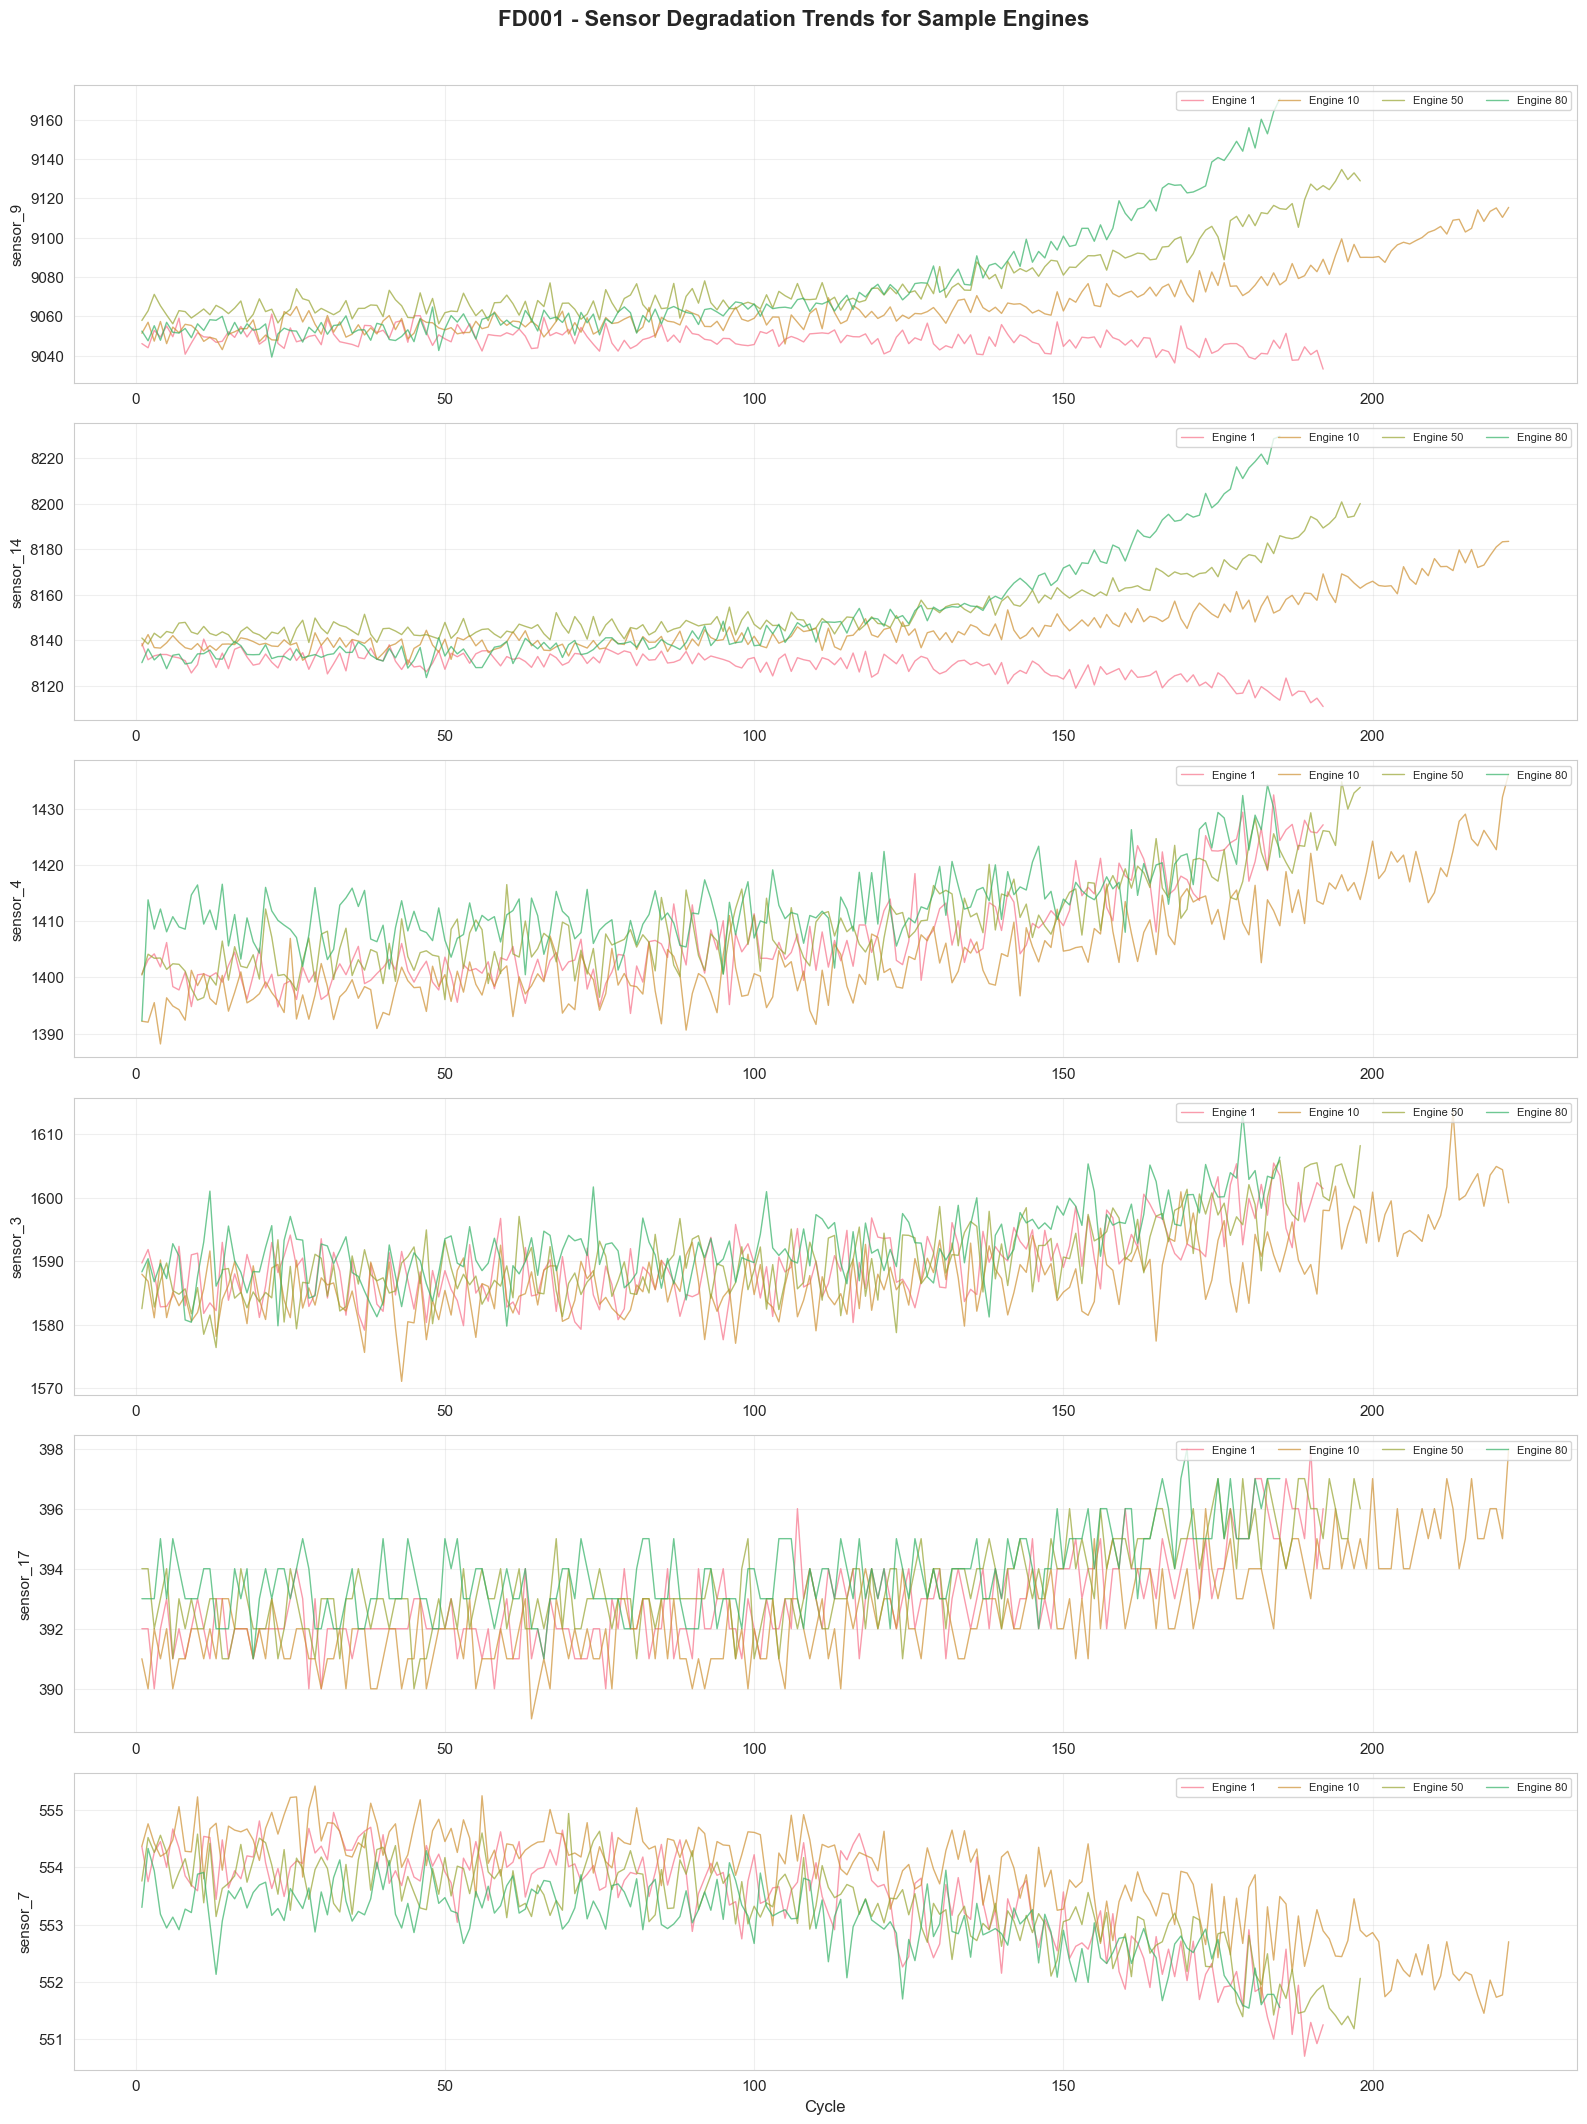

In [597]:
# Select a few representative engines to show degradation trends
sample_engines = [1, 10, 50, 80]

# Pick top sensors with highest variance (most informative)
top_sensors = variances.head(6).index.tolist()

fig, axes = plt.subplots(len(top_sensors), 1, figsize=(16, 3.5 * len(top_sensors)), sharex=False)
fig.suptitle('FD001 - Sensor Degradation Trends for Sample Engines', fontsize=16, fontweight='bold', y=1.01)

for i, sensor in enumerate(top_sensors):
    ax = axes[i]
    for j, eng_id in enumerate(sample_engines):
        eng_data = df_fd1[df_fd1['unit_id'] == eng_id]
        ax.plot(eng_data['cycle'], eng_data[sensor], alpha=0.7, 
                label=f'Engine {eng_id}', linewidth=1, color=COLORS[j])
    ax.set_ylabel(sensor, fontsize=11)
    ax.legend(loc='upper right', fontsize=8, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Cycle', fontsize=12)
plt.tight_layout()
plt.show()

### 3.7 Sensor Trends vs RUL (FD001)

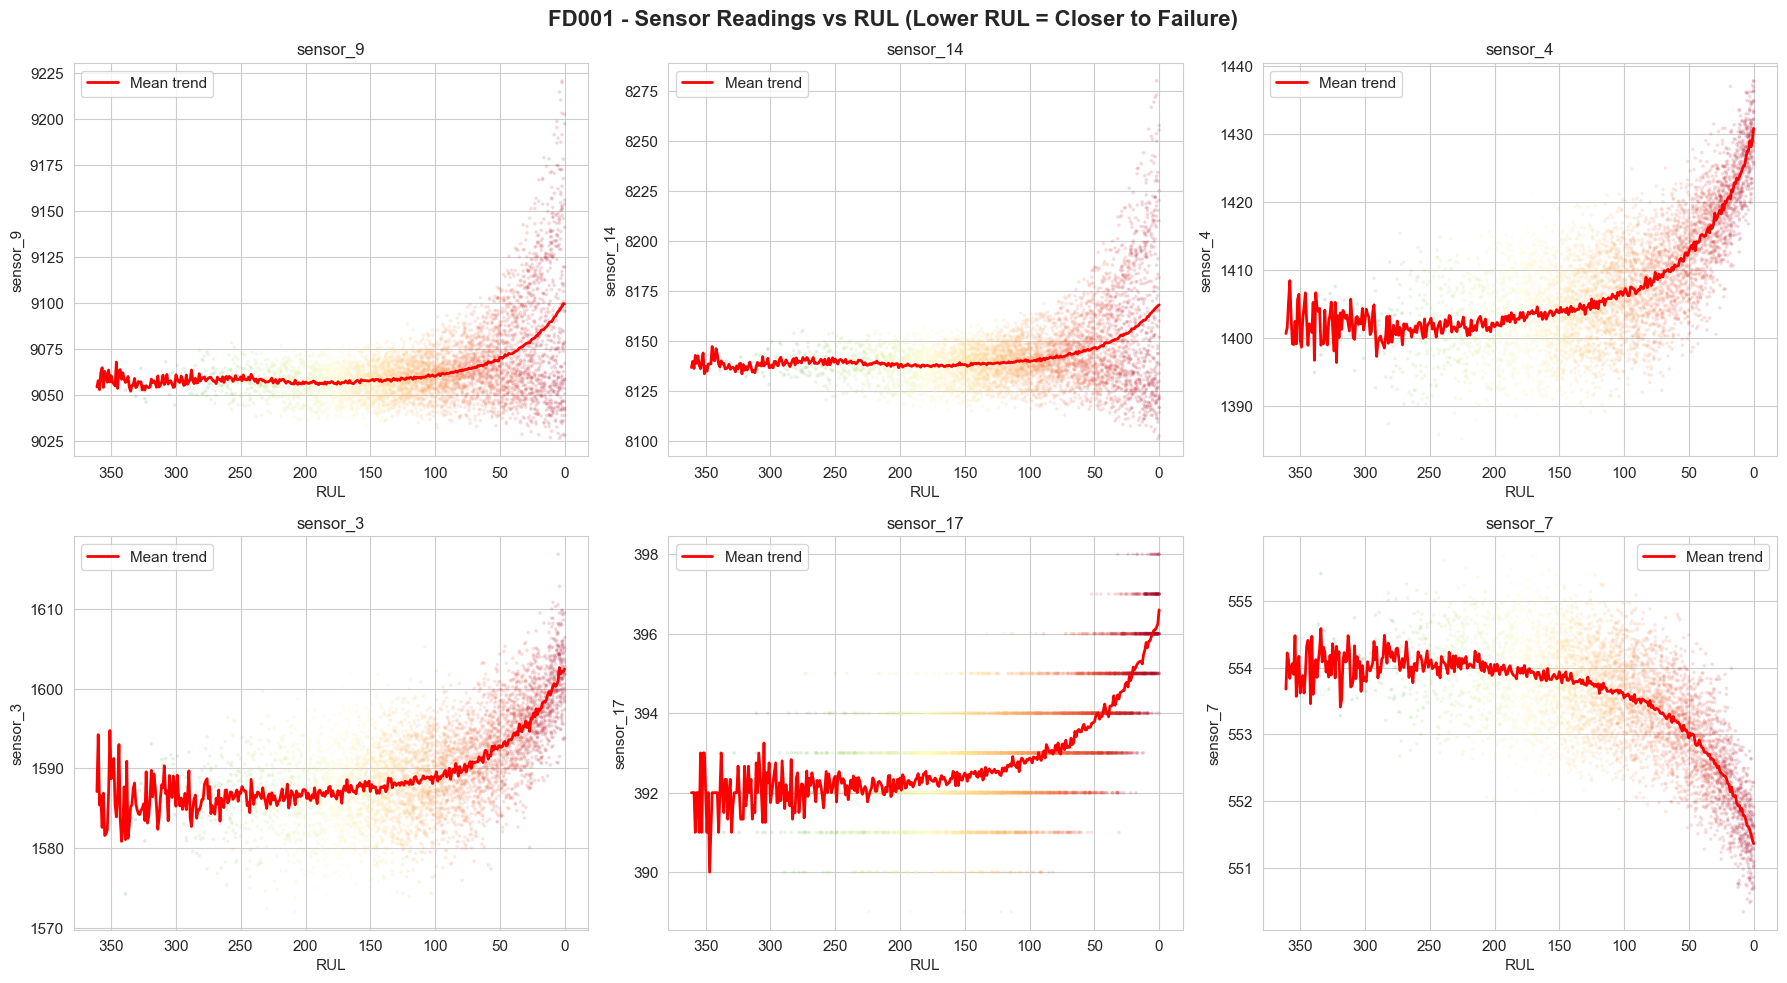

In [598]:
# Show sensor values against RUL to see degradation patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('FD001 - Sensor Readings vs RUL (Lower RUL = Closer to Failure)', fontsize=16, fontweight='bold')

for i, sensor in enumerate(top_sensors):
    ax = axes[i // 3][i % 3]
    # Sample for performance
    sample = df_fd1.sample(min(5000, len(df_fd1)), random_state=42)
    ax.scatter(sample['RUL'], sample[sensor], alpha=0.1, s=3, c=sample['RUL'], cmap='RdYlGn')
    
    # Add trend line with rolling mean
    trend = df_fd1.groupby('RUL')[sensor].mean()
    ax.plot(trend.index, trend.values, color='red', linewidth=2, label='Mean trend')
    
    ax.set_xlabel('RUL')
    ax.set_ylabel(sensor)
    ax.set_title(sensor, fontsize=12)
    ax.invert_xaxis()
    ax.legend()

plt.tight_layout()
plt.show()

### 3.8 Correlation Analysis

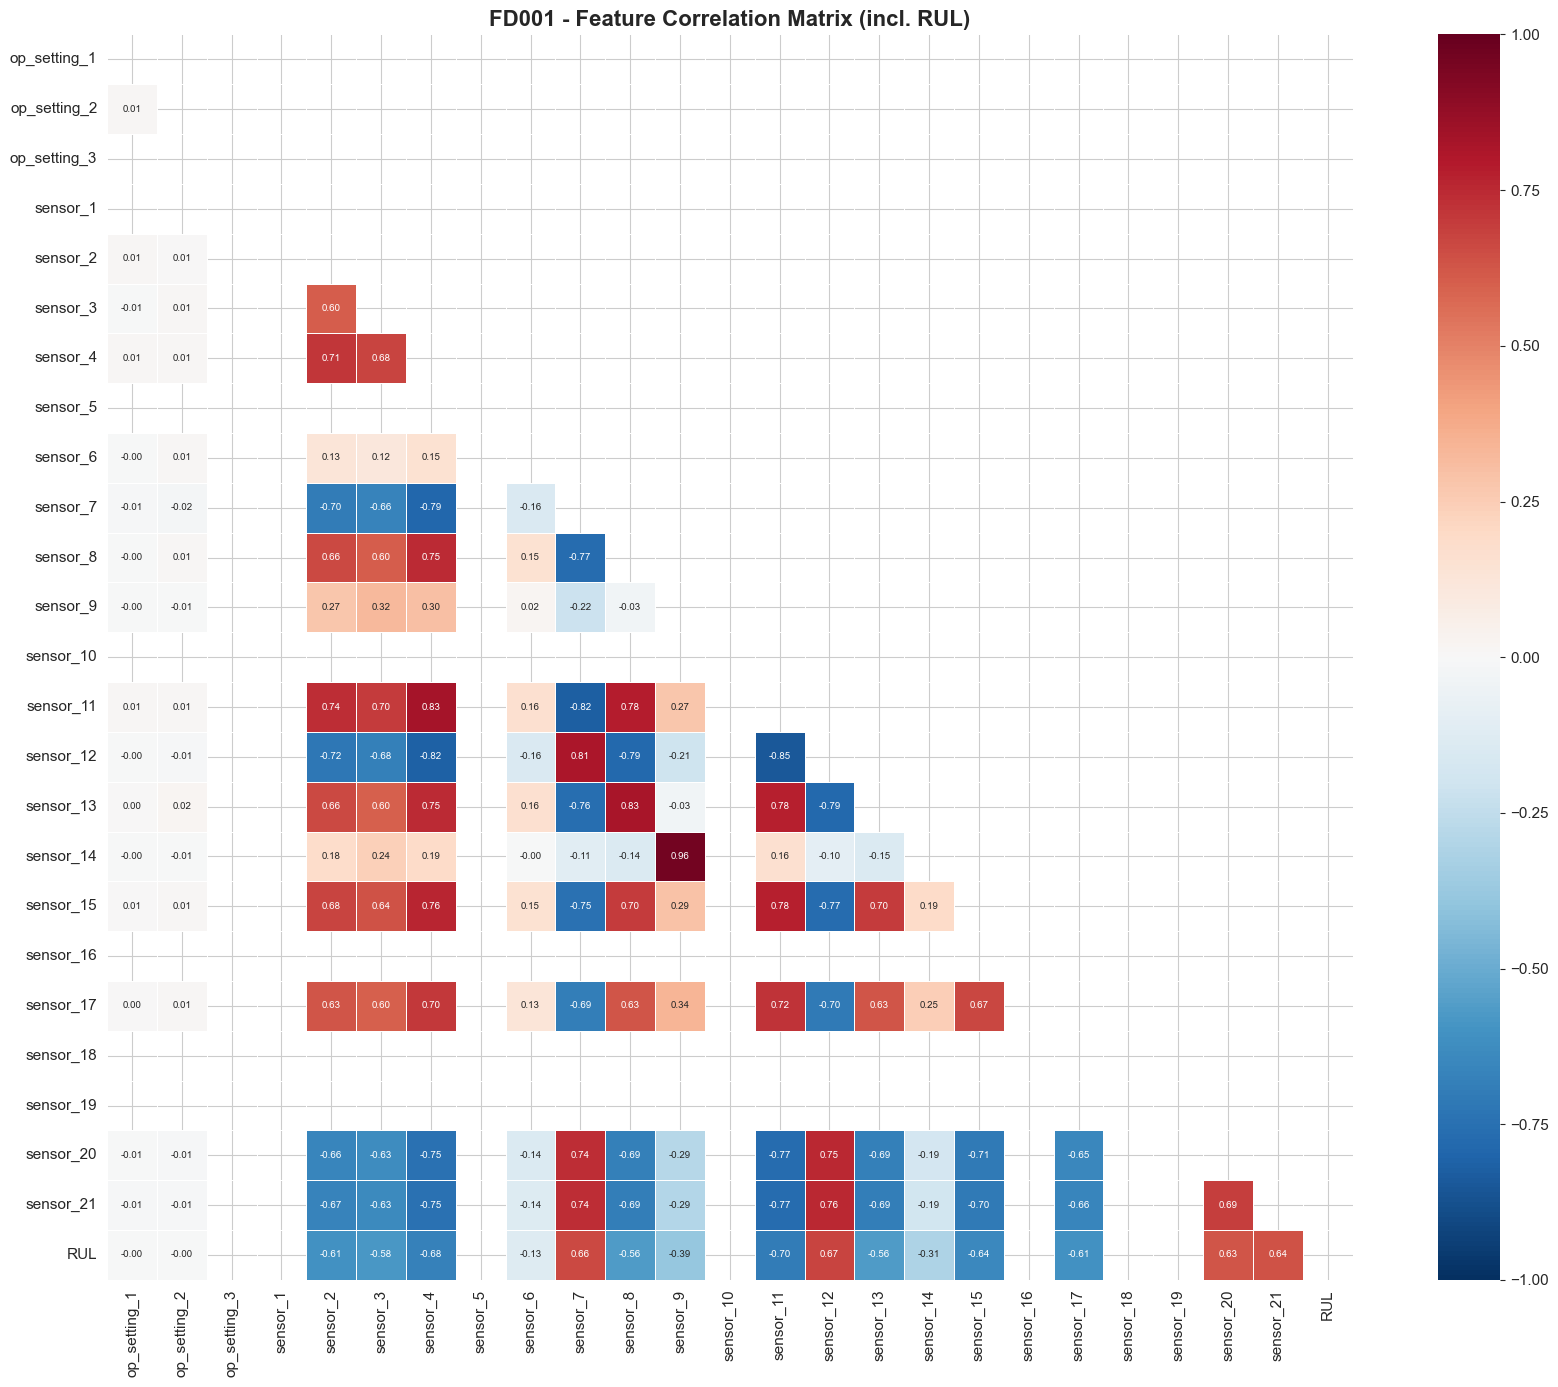

In [599]:
# Correlation heatmap (FD001 train)
fig, ax = plt.subplots(figsize=(18, 14))

corr_cols = op_cols + sensor_cols + ['RUL']
corr_matrix = df_fd1[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('FD001 - Feature Correlation Matrix (incl. RUL)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

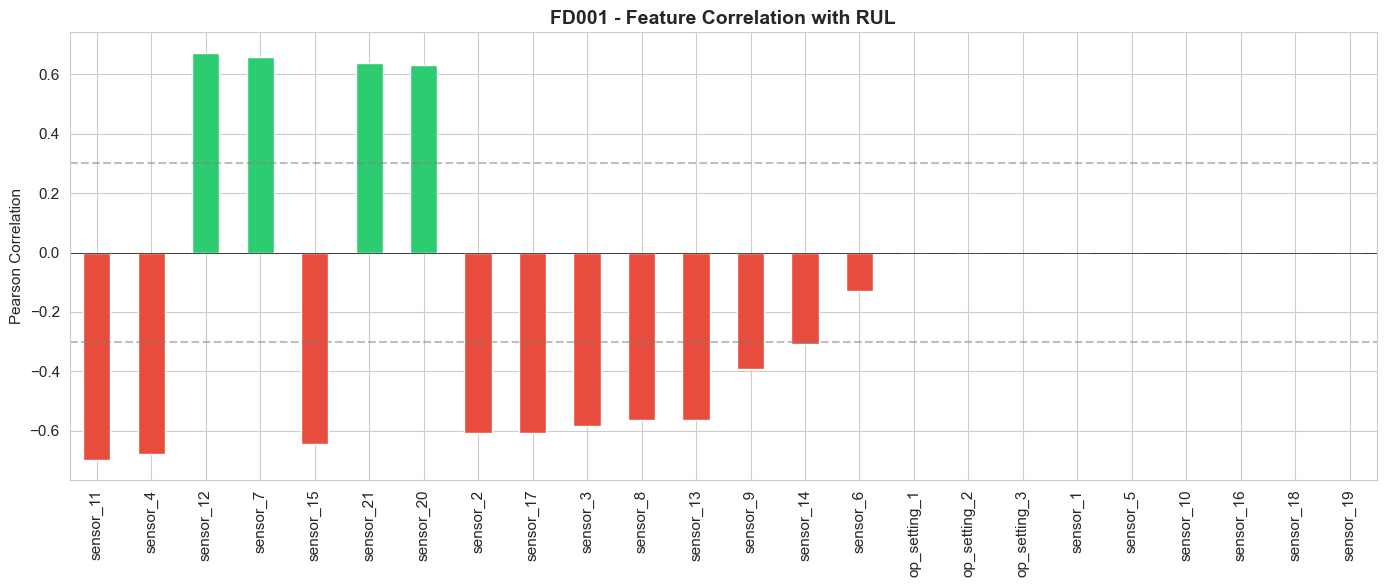


Top Features Correlated with RUL:
  - sensor_11: -0.6962 (Negative correlation)
  - sensor_4: -0.6789 (Negative correlation)
  - sensor_12: 0.6720 (Positive correlation)
  - sensor_7: 0.6572 (Positive correlation)
  - sensor_15: -0.6427 (Negative correlation)
  - sensor_21: 0.6357 (Positive correlation)
  - sensor_20: 0.6294 (Positive correlation)
  - sensor_2: -0.6065 (Negative correlation)
  - sensor_17: -0.6062 (Negative correlation)
  - sensor_3: -0.5845 (Negative correlation)


In [600]:
# Top correlations with RUL
rul_corr = df_fd1[corr_cols].corr()['RUL'].drop('RUL').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in rul_corr]
rul_corr.plot(kind='bar', ax=ax, color=colors_corr, edgecolor='white')
ax.set_title('FD001 - Feature Correlation with RUL', fontsize=14, fontweight='bold')
ax.set_ylabel('Pearson Correlation')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=-0.3, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nTop Features Correlated with RUL:')
for feat, corr_val in rul_corr.head(10).items():
    direction = 'Positive' if corr_val > 0 else 'Negative'
    print(f'  - {feat}: {corr_val:.4f} ({direction} correlation)')

Danh sách được sắp xếp theo giá trị tuyệt đối (abs), không phải theo giá trị thô. Vì trong bài toán dự đoán, cả tương quan dương lẫn âm đều có giá trị dự đoán cao. Cái quan trọng là |r| càng lớn càng tốt (càng gần 1 hoặc -1): Một sensor có r = +0.05 → |0.05| = gần 0 → vô dụng

### 3.9 Highly Correlated Sensor Pairs (Multicollinearity)

In [601]:
# Find highly correlated sensor pairs
sensor_corr = df_fd1[sensor_cols].corr()

# Get upper triangle pairs
high_corr_pairs = []
for i in range(len(sensor_corr.columns)):
    for j in range(i+1, len(sensor_corr.columns)):
        if abs(sensor_corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Sensor A': sensor_corr.columns[i],
                'Sensor B': sensor_corr.columns[j],
                'Correlation': round(sensor_corr.iloc[i, j], 4)
            })

if high_corr_pairs:
    print(f'Found {len(high_corr_pairs)} highly correlated sensor pairs (|r| > 0.9):')
    display(pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False))
else:
    print('No highly correlated sensor pairs found.')

Found 1 highly correlated sensor pairs (|r| > 0.9):


,Sensor A,Sensor B,Correlation
0,sensor_9,sensor_14,0.9632


### 3.10 Outlier Detection

OUTLIER DETECTION (IQR Method) - FD001 Train


,Sensor,Outliers,Pct (%),IQR
8,sensor_9,1686,8.17,16.3200
13,sensor_14,1543,7.48,15.0650
5,sensor_6,406,1.97,0.0000
7,sensor_8,320,1.55,0.0900
10,sensor_11,167,0.81,0.3500
2,sensor_3,165,0.80,8.1200
12,sensor_13,161,0.78,0.1000
11,sensor_12,146,0.71,0.9900
20,sensor_21,136,0.66,0.1450
1,sensor_2,128,0.62,0.6750


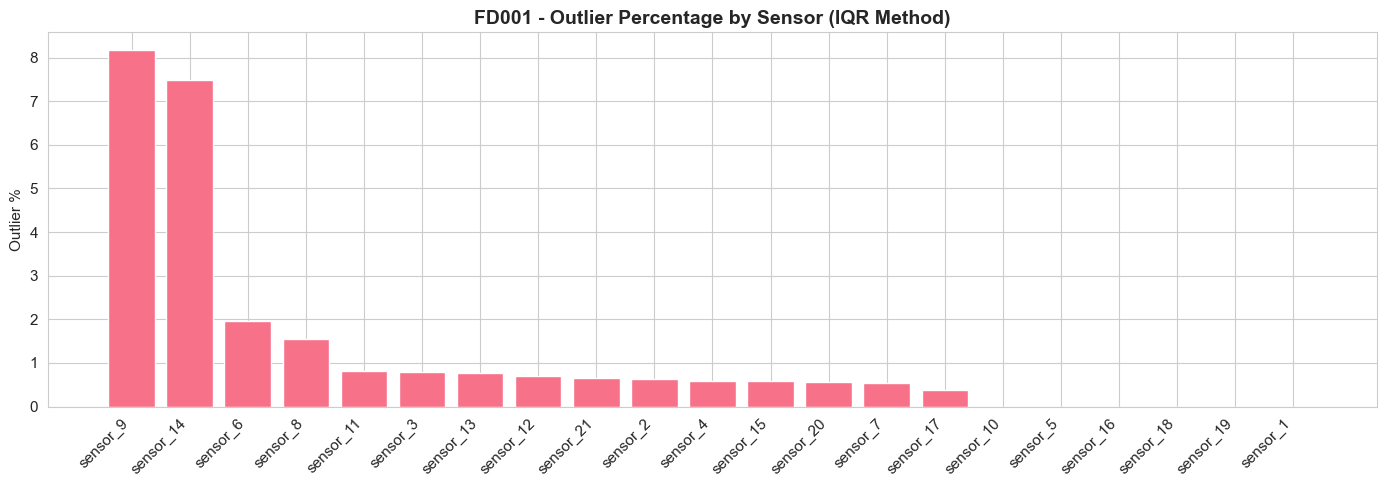

In [602]:
# IQR-based outlier detection for each sensor (FD001)
print('='*60)
print('OUTLIER DETECTION (IQR Method) - FD001 Train')
print('='*60)

outlier_summary = []
for sensor in sensor_cols:
    Q1 = df_fd1[sensor].quantile(0.25)
    Q3 = df_fd1[sensor].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_fd1[sensor] < lower) | (df_fd1[sensor] > upper)).sum()
    pct = 100 * n_outliers / len(df_fd1)
    outlier_summary.append({
        'Sensor': sensor,
        'Outliers': n_outliers,
        'Pct (%)': round(pct, 2),
        'IQR': round(IQR, 4)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Pct (%)', ascending=False)
display(outlier_df)

# Visualize
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(outlier_df['Sensor'], outlier_df['Pct (%)'], color=COLORS[0], edgecolor='white')
ax.set_title('FD001 - Outlier Percentage by Sensor (IQR Method)', fontsize=14, fontweight='bold')
ax.set_ylabel('Outlier %')
ax.set_xticklabels(outlier_df['Sensor'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.11 Cross-Dataset Comparison

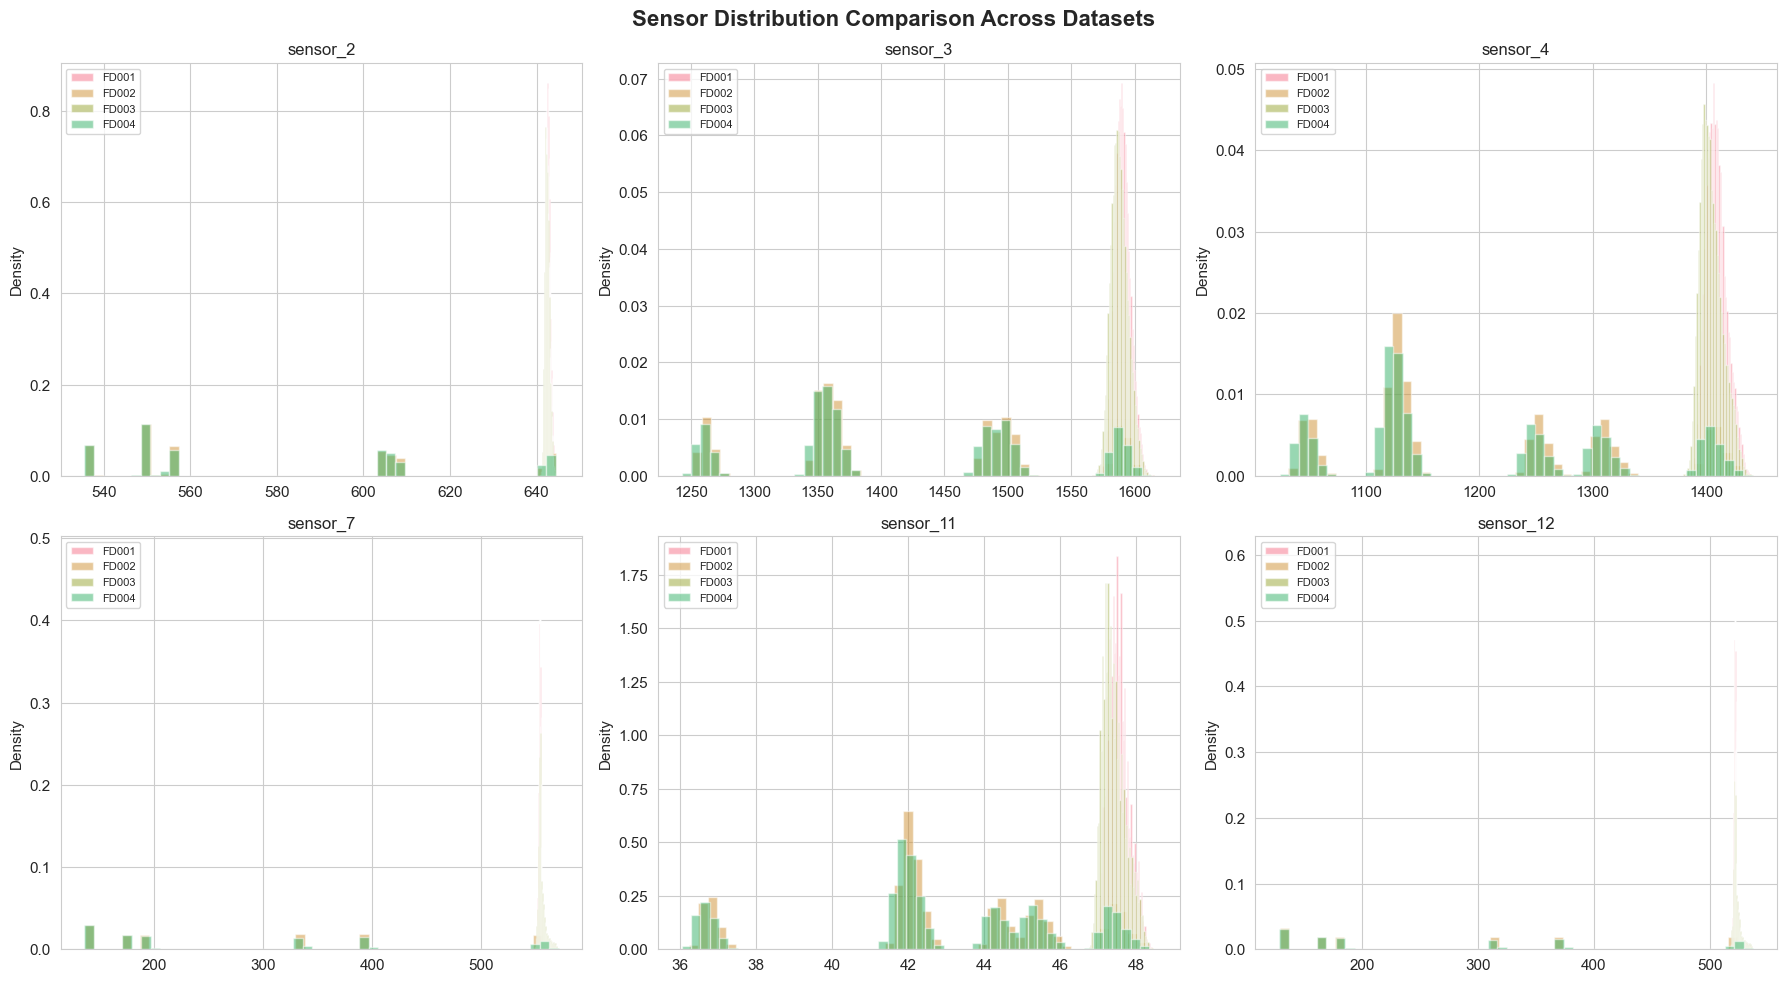

In [603]:
# Compare sensor distributions across all 4 datasets
compare_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sensor Distribution Comparison Across Datasets', fontsize=16, fontweight='bold')

for i, sensor in enumerate(compare_sensors):
    ax = axes[i // 3][i % 3]
    for j, fd in enumerate(['FD001', 'FD002', 'FD003', 'FD004']):
        data = datasets[fd]['train'][sensor]
        ax.hist(data, bins=50, alpha=0.5, label=fd, density=True, color=COLORS[j])
    ax.set_title(sensor, fontsize=12)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

### 3.12 Single Engine Deep Dive (FD001 - Engine #1)

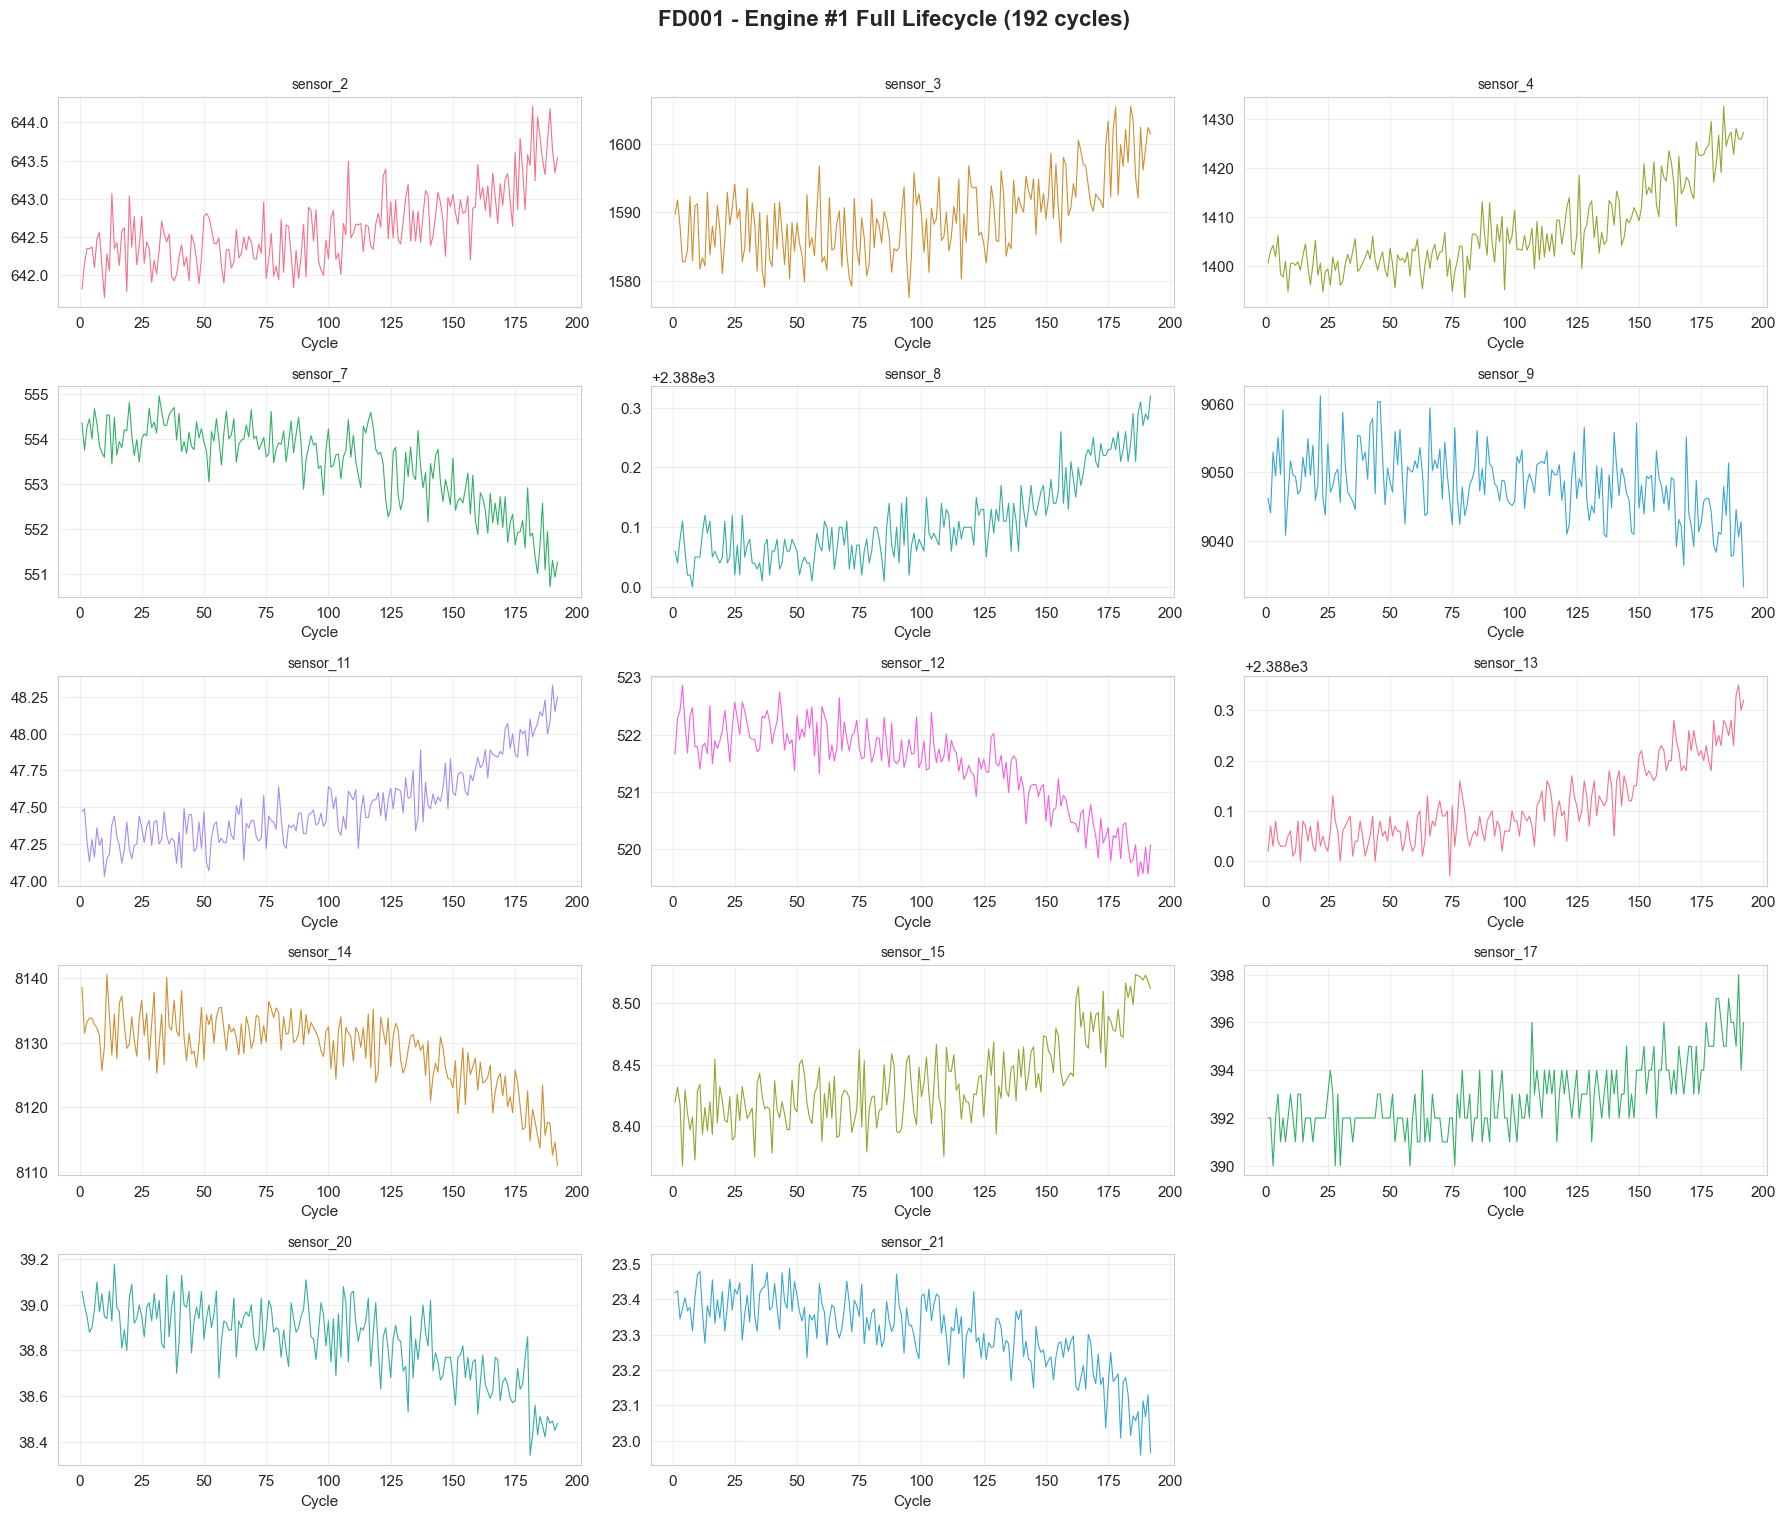

In [604]:
# Full lifecycle of Engine 1
eng1 = df_fd1[df_fd1['unit_id'] == 1].copy()

informative_sensors = [s for s in sensor_cols if s not in constant_sensors]
n_sensors = len(informative_sensors)
n_cols_plot = 3
n_rows_plot = (n_sensors + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 3 * n_rows_plot))
fig.suptitle(f'FD001 - Engine #1 Full Lifecycle ({len(eng1)} cycles)', fontsize=16, fontweight='bold', y=1.01)

for i, sensor in enumerate(informative_sensors):
    ax = axes[i // n_cols_plot][i % n_cols_plot]
    ax.plot(eng1['cycle'], eng1[sensor], linewidth=0.8, color=COLORS[i % 8])
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel('Cycle')
    ax.grid(True, alpha=0.3)

# Remove empty subplots
for i in range(n_sensors, n_rows_plot * n_cols_plot):
    axes[i // n_cols_plot][i % n_cols_plot].set_visible(False)

plt.tight_layout()
plt.show()

---
## 4. Summary & Key Findings

In [605]:
print('='*70)
print('DATA VALIDATION & EDA SUMMARY')
print('='*70)

print('\n1. DATA INTEGRITY:')
print('   - No missing values in any dataset.')
print('   - No duplicate (unit_id, cycle) pairs.')
print('   - All columns are numeric.')
print('   - Cycles are continuous (1, 2, ..., N) for each engine.')
print('   - RUL file row count matches test engine count.')

print('\n2. DATASET STRUCTURE:')
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = datasets[fd]
    print(f'   - {fd}: {d["train"]["unit_id"].nunique()} train engines, '
          f'{d["test"]["unit_id"].nunique()} test engines, '
          f'{d["train"].shape[0]} train rows')

print('\n3. CONSTANT/UNINFORMATIVE FEATURES (FD001):')
print(f'   - Sensors with near-zero variance: {constant_sensors}')
print(f'   -> These can be safely removed in preprocessing.')

print('\n4. KEY OBSERVATIONS:')
print('   - FD001 & FD003: Single operating condition (tight sensor distributions).')
print('   - FD002 & FD004: Multiple operating conditions (wider sensor distributions).')
print('   - Many sensors show clear degradation trends near end of life.')
print('   - High multicollinearity between several sensor pairs (|r|>0.9).')
print('   - Engine lifetimes vary significantly (different initial wear levels).')

print('\n5. TOP SENSORS CORRELATED WITH RUL (FD001):')
for feat, corr_val in rul_corr.head(5).items():
    print(f'   - {feat}: r = {corr_val:.4f}')

print('\n6. RECOMMENDATIONS FOR MODELING:')
print('   - Remove constant sensors to reduce dimensionality.')
print('   - Consider normalizing/standardizing sensor data (especially FD002/FD004).')
print('   - Clip RUL at a max threshold (e.g., 125) — early cycles are not informative.')
print('   - Address multicollinearity via PCA or feature selection.')
print('   - For FD002/FD004, normalize by operating condition or use regime-based features.')

DATA VALIDATION & EDA SUMMARY

1. DATA INTEGRITY:
   - No missing values in any dataset.
   - No duplicate (unit_id, cycle) pairs.
   - All columns are numeric.
   - Cycles are continuous (1, 2, ..., N) for each engine.
   - RUL file row count matches test engine count.

2. DATASET STRUCTURE:
   - FD001: 100 train engines, 100 test engines, 20631 train rows
   - FD002: 260 train engines, 259 test engines, 53759 train rows
   - FD003: 100 train engines, 100 test engines, 24720 train rows
   - FD004: 249 train engines, 248 test engines, 61249 train rows

3. CONSTANT/UNINFORMATIVE FEATURES (FD001):
   - Sensors with near-zero variance: ['sensor_6', 'sensor_5', 'sensor_16', 'sensor_10', 'sensor_18', 'sensor_19', 'sensor_1']
   -> These can be safely removed in preprocessing.

4. KEY OBSERVATIONS:
   - FD001 & FD003: Single operating condition (tight sensor distributions).
   - FD002 & FD004: Multiple operating conditions (wider sensor distributions).
   - Many sensors show clear degradatio

## 📖 Tổng quan về Dataset

### NASA Turbofan Jet Engine (C-MAPSS)

Đây là bộ dữ liệu mô phỏng **quá trình suy giảm (degradation) của động cơ phản lực turbofan**, được tạo bởi NASA sử dụng phần mềm C-MAPSS. Mục tiêu chính là **dự đoán Remaining Useful Life (RUL)** — tức số chu kỳ hoạt động còn lại trước khi động cơ hỏng.

### Cấu trúc dữ liệu

Bộ dữ liệu gồm **4 sub-datasets** với độ phức tạp tăng dần:

| Dataset | Train Engines | Test Engines | Điều kiện vận hành | Loại lỗi |
|---------|:---:|:---:|---|---|
| **FD001** | 100 | 100 | 1 (Sea Level) | 1 (HPC Degradation) |
| **FD002** | 260 | 259 | 6 điều kiện | 1 (HPC Degradation) |
| **FD003** | 100 | 100 | 1 (Sea Level) | 2 (HPC + Fan) |
| **FD004** | 248 | 249 | 6 điều kiện | 2 (HPC + Fan) |

- **FD001** là đơn giản nhất (1 điều kiện, 1 loại lỗi) → thường dùng làm baseline.
- **FD004** là phức tạp nhất (6 điều kiện, 2 loại lỗi).

### Mỗi file có gì?

Mỗi sub-dataset gồm 3 file:

- **`train_FDxxx.txt`** — Dữ liệu train, mỗi engine chạy **đến khi hỏng hoàn toàn** (run-to-failure).
- **`test_FDxxx.txt`** — Dữ liệu test, mỗi engine **dừng ở giữa chừng** trước khi hỏng → ta cần dự đoán còn bao lâu nữa mới hỏng.
- **`RUL_FDxxx.txt`** — RUL thật sự của mỗi engine trong test set (ground truth).

### 26 Cột dữ liệu

| Cột | Ý nghĩa |
|-----|---------|
| `unit_id` | Mã động cơ |
| `cycle` | Chu kỳ thời gian (1, 2, 3, ...) |
| `op_setting_1-3` | 3 thông số vận hành (nhiệt độ, áp suất, tốc độ...) |
| `sensor_1-21` | 21 cảm biến đo đạc (nhiệt độ đầu ra, áp suất, tốc độ quạt, v.v.) |

---

## 📊 File EDA đã làm những gì?

Notebook [EDA_NASA_Turbofan.ipynb](cci:7://file:///d:/NAM_3%20KI_2/DataMining/doan/archive%20%284%29/EDA_NASA_Turbofan.ipynb:0:0-0:0) gồm **2 phần lớn**:

### Phần 1: Data Validation (Kiểm tra dữ liệu)

| Kiểm tra | Mục đích |
|-----------|----------|
| **Shape & Overview** | Đếm số dòng, cột, số engines mỗi dataset |
| **Missing Values** | Có giá trị thiếu không? |
| **Duplicates** | Có dòng trùng hoặc cặp `(unit_id, cycle)` trùng không? |
| **Data Types** | Tất cả cột có phải numeric không? |
| **Constant Sensors** | Sensor nào có variance ≈ 0 (không mang thông tin)? |
| **Cycle Continuity** | Mỗi engine có chạy liên tục từ cycle 1 → N không? |

### Phần 2: EDA (Khám phá dữ liệu)

| Phân tích | Mô tả |
|-----------|-------|
| **Engine Lifetime** | Histogram tuổi thọ mỗi engine (min/max/mean) |
| **RUL Distribution** | Phân phối RUL thật trong test set |
| **Operational Settings** | Scatter plot 3 thông số vận hành → phân biệt FD001/FD003 (1 cụm) vs FD002/FD004 (nhiều cụm) |
| **Sensor Box Plots** | So sánh phân phối 21 sensors |
| **Variance Analysis** | Xác định sensors hữu ích vs vô dụng (constant) |
| **Degradation Trends** | Vẽ sensor theo thời gian → thấy xu hướng suy giảm |
| **Sensor vs RUL** | Mối quan hệ sensor với RUL (có trend line) |
| **Correlation Heatmap** | Ma trận tương quan giữa tất cả features + RUL |
| **Top Features** | Xếp hạng features có tương quan mạnh nhất với RUL |
| **Multicollinearity** | Tìm cặp sensor có tương quan > 0.9 (cần xử lý) |
| **Outlier Detection** | Phát hiện outliers bằng phương pháp IQR |
| **Cross-Dataset** | So sánh phân phối sensor giữa 4 datasets |
| **Engine Deep Dive** | Vẽ chi tiết toàn bộ lifecycle của Engine #1 |
| **Summary** | Tóm tắt findings + gợi ý cho bước modeling |

---

### 💡 Những điều quan trọng bạn sẽ thấy khi chạy notebook:

1. **Một số sensors gần như không đổi** (sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19) → có thể loại bỏ.
2. **Nhiều cặp sensors tương quan rất cao** (>0.9) → cần xử lý multicollinearity (PCA hoặc feature selection).
3. **FD002/FD004 phức tạp hơn** vì có nhiều operating conditions → cần normalize theo điều kiện vận hành.
4. **Sensors cho thấy xu hướng degradation rõ ràng** gần cuối đời → RUL prediction là khả thi.


# Data processing

# Giai đoạn 1: Làm sạch mảng (Data Purging) & Khởi tạo Nhãn (Labeling) 

### Task 1.1 + 1.2: Loại bỏ các sensor không có giá trị: std ~ 0 và kiểm tra các sensor có giá trị biến động rất nhỏ

Trong hệ thống của máy bay, 3 cột này đại diện cho các điều kiện môi trường do phi công điều khiển:

op_setting_1: Độ cao bay (Altitude)

op_setting_2: Tốc độ bay (Mach Number)

op_setting_3: Góc mở bướm ga (Throttle Resolver Angle)

Tuy nhiên, ở fd001 và fd003, chỉ có 1 điều kiện bay là so với mực nước biển, trong điều kiện này phi công không thay đổi bướm ga, vì thế std = 0 nên cần được xóa bỏ, và ở op1 và op2 cũng tương tự, không thay đổi độ cao và tốc độ bay, giá trị chỉ nhúc nhích một chút (white noise) nên cũng áp dụng xóa bỏ

Có 2 near - constant sensor ở fd001 là 16 và ở fd003 là 10, sẽ không vội xóa, mà tính ma trận tương quan để xem có ý nghĩa mặt giá trị hay không rồi mới quyết định xóa hay không


========== [FD001] TASK 1.1 & 1.2: SENSOR AND FEATURE FILTERING ==========
Dropped 7 Constant columns: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'op_setting_3']
Dropped 2 Near-constant columns (meaningless noise, corr < 0.1): ['op_setting_1', 'op_setting_2']
Successfully KEPT Near-constant columns (with trend):
    -> sensor_6 (Correlation with cycle: 0.1060)
Final number of columns retained (including unit_id, cycle, RUL if any): 18

========== [FD002] TASK 1.1 & 1.2: SENSOR AND FEATURE FILTERING ==========
Dropped 0 Constant columns: []
Dropped 1 Near-constant columns (meaningless noise, corr < 0.1): ['sensor_16']
Final number of columns retained (including unit_id, cycle, RUL if any): 26

========== [FD003] TASK 1.1 & 1.2: SENSOR AND FEATURE FILTERING ==========
Dropped 6 Constant columns: ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19', 'op_setting_3']
Dropped 2 Near-constant columns (meaningless noise, corr < 0.1): ['op_setting_1'

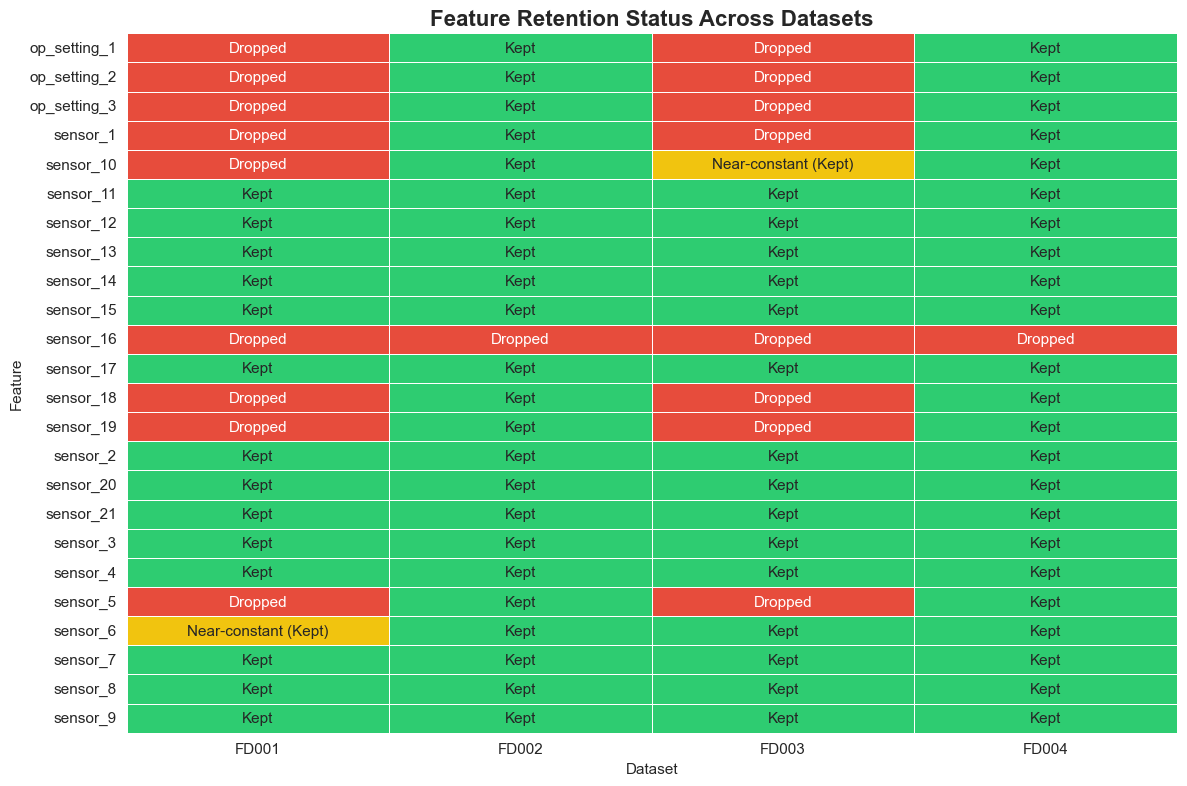

In [606]:
target_fds = ['FD001', 'FD002', 'FD003', 'FD004']
feature_cols = [f'sensor_{i}' for i in range(1, 22)] + [f'op_setting_{i}' for i in range(1, 4)]

for fd in target_fds:
    print(f"\n{'='*10} [{fd}] TASK 1.1 & 1.2: SENSOR AND FEATURE FILTERING {'='*10}")
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # Calculate standard deviation of features
    std_vals = train_df[feature_cols].std()
    
    # 1. Group Constant features
    constant_cols = std_vals[std_vals < 1e-6].index.tolist()
    
    # 2. Group Near-constant features for testing
    near_constant_cols = std_vals[(std_vals >= 1e-6) & (std_vals < 0.01)].index.tolist()
    
    # 3. Classify Near-constant features using Correlation Test
    cols_to_drop = constant_cols.copy() # Start drop list with Constant columns
    kept_near_constant = []             # List for saved features
    
    for col in near_constant_cols:
        corr = train_df[col].corr(train_df['cycle'])
        
        # If random fluctuation (low correlation), add to drop list
        if abs(corr) < 0.1 or pd.isna(corr):
            cols_to_drop.append(col)
        # If there is a clear trend, keep it
        else:
            kept_near_constant.append((col, corr))
            
    # 4. Perform drop operation once on both Train and Test sets
    datasets[fd]['train'] = train_df.drop(columns=cols_to_drop)
    datasets[fd]['test'] = test_df.drop(columns=cols_to_drop)
    
    # --- PRINT RESULTS ---
    print(f"Dropped {len(constant_cols)} Constant columns: {constant_cols}")
    
    # Find near-constant columns that were dropped
    dropped_near = [c for c in cols_to_drop if c not in constant_cols]
    print(f"Dropped {len(dropped_near)} Near-constant columns (meaningless noise, corr < 0.1): {dropped_near}")
    
    if kept_near_constant:
        print(f"Successfully KEPT Near-constant columns (with trend):")
        for col, corr in kept_near_constant:
            print(f"    -> {col} (Correlation with cycle: {corr:.4f})")
            
    print(f"Final number of columns retained (including unit_id, cycle, RUL if any): {datasets[fd]['train'].shape[1]}")

print("\n" + "="*60)
print("Cleaning process complete! Useful sensors have been preserved.")

#Xuất ra một biểu đồ thể hiện chi tiết các cột bị loại bỏ và giữ lại cho mỗi tập dữ liệu phân biệt bằng màu sắc, ví dụ fd001 thì sensor_1 bị drop màu đỏ, sensor_2 bị giữ lại màu xanh lá, v.v. Biểu đồ có thể là một bar chart hoặc một heatmap để dễ dàng so sánh giữa các tập dữ liệu.
# Prepare data for visualization
visualization_data = []

for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    train_df_fd = datasets[fd]['train']
    train_cols = set(train_df_fd.columns)

    # Near-constant features that are still kept after filtering
    std_kept = train_df_fd[[c for c in feature_cols if c in train_cols]].std()
    near_constant_kept = set(std_kept[(std_kept >= 1e-6) & (std_kept < 0.01)].index)

    for col in feature_cols:
        if col not in train_cols:
            plot_status = 'Dropped'
        elif col in near_constant_kept:
            plot_status = 'Near-constant (Kept)'
        else:
            plot_status = 'Kept'

        visualization_data.append({
            'Dataset': fd,
            'Feature': col,
            'PlotStatus': plot_status
        })

vis_df = pd.DataFrame(visualization_data)

pivot_table = vis_df.pivot(index='Feature', columns='Dataset', values='PlotStatus')
status_num = pivot_table.replace({
    'Dropped': 0,
    'Near-constant (Kept)': 1,
    'Kept': 2
}).astype(float)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    status_num,
    annot=pivot_table,
    fmt='',
    cmap=sns.color_palette(['#e74c3c', '#f1c40f', '#2ecc71'], as_cmap=True),  # red, yellow, green
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    vmin=0, vmax=2
)

ax.set_title('Feature Retention Status Across Datasets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### Task 1.3 - Khởi tạo Nhãn Piecewise RUL.

Gán cho RUL = 125 với các động "mới vận hành" tức là ở các chu kì đầu từ 1 = 50 thì chu kì còn lại vẫn còn lâu, vẫn còn vận hành trơn tru nên chỉ gán RUL = 125 cho các chu kì đầu, khi nào xuống dưới 125 thì mới bắt đầu đếm ngược chính xác


[FD001] TASK 1.3: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (20631, 18)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    190    2
       1    191    1
       1    192    0

[FD002] TASK 1.3: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (53759, 26)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    147    2
       1    148    1
       1    149    0

[FD003] TASK 1.3: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (24720, 19)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    257    2
       1    258    1
       1    259    0

[FD004] TASK 1.3: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label

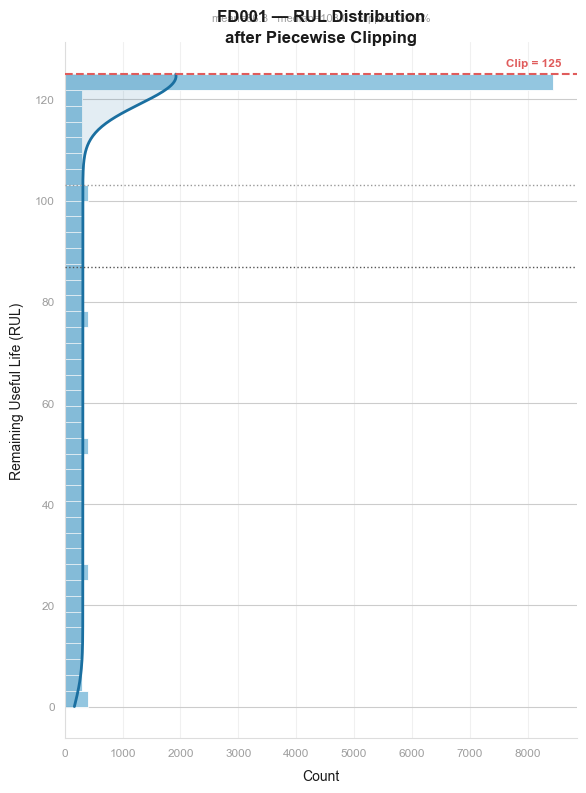

In [607]:
# Cài đặt ngưỡng RUL tối đa (Piecewise RUL)
MAX_RUL = 125
target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

for fd in target_fds:
    print(f"\n[{fd}] TASK 1.3: INITIALIZING PIECEWISE RUL LABEL (MAX = {MAX_RUL})")
    train_df = datasets[fd]['train']
    
    # 1. Find the maximum lifetime (max_cycle) for each engine (unit_id)
    max_cycle_df = train_df.groupby('unit_id')['cycle'].max().reset_index()
    max_cycle_df.columns = ['unit_id', 'max_cycle']
    
    # 2. Merge the max_cycle column back into the original training dataframe
    train_df = train_df.merge(max_cycle_df, on='unit_id', how='left')
    
    # 3. Calculate linear RUL (RUL = Total lifetime - Current cycle)
    train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
    
    # 4. Apply Piecewise technique: Clip RUL at MAX_RUL (125)
    train_df['RUL'] = train_df['RUL'].clip(upper=MAX_RUL)
    
    # 5. Clean up: Remove the intermediate max_cycle column
    train_df.drop(columns=['max_cycle'], inplace=True)
    
    # Update the dictionary
    datasets[fd]['train'] = train_df
    
    print(f"Successfully created RUL label. Train set size: {train_df.shape}")
    
    # Display the first 3 and last 3 cycles of unit_id = 1 for verification
    print(f"Verifying RUL for unit_id = 1:")
    display_df = pd.concat([
        train_df[train_df['unit_id'] == 1].head(3),
        train_df[train_df['unit_id'] == 1].tail(3)
    ])
    print(display_df[['unit_id', 'cycle', 'RUL']].to_string(index=False))

print("\n" + "="*60)
print("Stage 1 Complete! We now have accurate labels for model training.")

fd       = 'FD001'
train_df = datasets[fd]['train']

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

C_BAR  = '#93C6E0'
C_LINE = '#1A6FA0'
C_CLIP = '#E05C5C'
C_TEXT = '#1A1A1A'
C_MUTE = '#9E9E9E'
C_GRID = '#F0F0F0'

rul = train_df['RUL']

fig, ax = plt.subplots(figsize=(6, 8), facecolor='white')   # ← đứng

# Histogram ngang → đứng (orientation='horizontal')
counts, edges, patches = ax.hist(
    rul, bins=40,
    color=C_BAR, edgecolor='white', linewidth=0.6,
    orientation='horizontal', zorder=2
)

# KDE (đổi trục: x=density, y=RUL value)
from scipy.stats import gaussian_kde
kde_y = np.linspace(rul.min(), rul.max(), 400)
kde_x = gaussian_kde(rul)(kde_y)
kde_x_scaled = kde_x * len(rul) * (edges[1] - edges[0])
ax.plot(kde_x_scaled, kde_y, color=C_LINE, lw=2, zorder=3)
ax.fill_betweenx(kde_y, kde_x_scaled, alpha=0.12, color=C_LINE, zorder=2)

# Đường clip MAX_RUL (nằm ngang trên trục Y)
ax.axhline(MAX_RUL, color=C_CLIP, lw=1.5, ls='--', zorder=4)
ax.text(ax.get_xlim()[1] * 0.97, MAX_RUL + 1.5,
        f'Clip = {MAX_RUL}',
        color=C_CLIP, fontsize=8.5, ha='right', fontweight='bold')

# Mean / Median
mean_rul   = rul.mean()
median_rul = rul.median()
pct_clipped = (rul == MAX_RUL).mean() * 100

ax.axhline(mean_rul,   color='#555', lw=1, ls=':', zorder=4)
ax.axhline(median_rul, color='#999', lw=1, ls=':', zorder=4)

# Grid dọc nhẹ (theo trục X giờ là Count)
ax.xaxis.grid(True, color=C_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

# Stats annotation
ax.text(0.5, 1.03,
        f"mean={mean_rul:.1f}   median={median_rul:.1f}   clipped: {pct_clipped:.1f}%",
        transform=ax.transAxes, ha='center', fontsize=8, color=C_MUTE)

# Labels & title
ax.set_ylabel('Remaining Useful Life (RUL)', fontsize=10, color=C_TEXT, labelpad=8)
ax.set_xlabel('Count', fontsize=10, color=C_TEXT, labelpad=8)
ax.tick_params(colors=C_MUTE, labelsize=8.5)

fig.text(0.5, 1.0,
         f'{fd} — RUL Distribution\nafter Piecewise Clipping',
         ha='center', fontsize=12, fontweight='bold', color=C_TEXT,
         transform=ax.transAxes, linespacing=1.5)

plt.tight_layout()
plt.savefig('rul_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [608]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("STARTING OPERATING CONDITION PROCESSING FOR FD002 & FD004")

complex_fds = ['FD002', 'FD004']
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
NUM_REGIMES = 6 

for fd in complex_fds:
    print(f"\n{'='*15} CLUSTERING & NORMALIZING {fd} {'='*15}")
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    sensor_cols = [c for c in train_df.columns if 'sensor' in c]
    
    # ---------------------------------------------------------
    # STEP 1: NORMALIZE OP_SETTINGS FOR K-MEANS
    # ---------------------------------------------------------
    op_scaler = StandardScaler()
    train_op_scaled = op_scaler.fit_transform(train_df[op_cols])
    test_op_scaled = op_scaler.transform(test_df[op_cols])

    # ---------------------------------------------------------
    # STEP 2: K-MEANS CLUSTERING ON SCALED DATA
    # ---------------------------------------------------------
    print("1. Performing K-Means clustering for 6 flight regimes...")
    kmeans = KMeans(n_clusters=NUM_REGIMES, random_state=42, n_init=10)
    train_df['regime'] = kmeans.fit_predict(train_op_scaled)
    test_df['regime'] = kmeans.predict(test_op_scaled)
    
    # ---------------------------------------------------------
    # STEP 3: NORMALIZE SENSORS PER REGIME
    # ---------------------------------------------------------
    print("2. Removing environmental noise (Condition-based Normalization)...")
    for regime in range(NUM_REGIMES):
        train_idx = train_df[train_df['regime'] == regime].index
        test_idx = test_df[test_df['regime'] == regime].index
        
        scaler = StandardScaler()
        train_df.loc[train_idx, sensor_cols] = scaler.fit_transform(train_df.loc[train_idx, sensor_cols])
        
        if len(test_idx) > 0:
            test_df.loc[test_idx, sensor_cols] = scaler.transform(test_df.loc[test_idx, sensor_cols])
            
    # Clean up
    train_df.drop(columns=op_cols + ['regime'], inplace=True)
    test_df.drop(columns=op_cols + ['regime'], inplace=True)
    
    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df
    
    print("Completed! Environmental noise has been successfully removed.")

STARTING OPERATING CONDITION PROCESSING FOR FD002 & FD004

=============== CLUSTERING & NORMALIZING FD002 ===============
1. Performing K-Means clustering for 6 flight regimes...
2. Removing environmental noise (Condition-based Normalization)...
Completed! Environmental noise has been successfully removed.

=============== CLUSTERING & NORMALIZING FD004 ===============
1. Performing K-Means clustering for 6 flight regimes...
2. Removing environmental noise (Condition-based Normalization)...
Completed! Environmental noise has been successfully removed.


# Giai đoạn 2: 

Làm mượt tín hiệu (EMA - Exponential Moving Average): Tín hiệu cảm biến thực tế luôn bị rung lắc (nhiễu tần số cao). Làm mượt sẽ giúp mô hình nhìn thấy rõ "đường cong suy thoái" của động cơ hơn.


========== [FD001] STAGE 2 - TASK 2.1: SIGNAL SMOOTHING (EMA) ==========
Applied EMA filter (span=10) to smooth 15 sensors.
Verifying 'sensor_2' for unit_id=1 (Train) after smoothing:
[641.82, 641.88, 641.9654545454545, 642.0353719008262, 642.0962133734032]

========== [FD002] STAGE 2 - TASK 2.1: SIGNAL SMOOTHING (EMA) ==========
Applied EMA filter (span=10) to smooth 20 sensors.
Verifying 'sensor_1' for unit_id=1 (Train) after smoothing:
[5.684341886080802e-14, 4.6508251795206554e-14, 3.8052206014259904e-14, 3.1133623102576284e-14, 2.547296435665332e-14]

========== [FD003] STAGE 2 - TASK 2.1: SIGNAL SMOOTHING (EMA) ==========
Applied EMA filter (span=10) to smooth 16 sensors.
Verifying 'sensor_2' for unit_id=1 (Train) after smoothing:
[642.36, 642.3854545454545, 642.3480991735537, 642.4520811419984, 642.3117027525441]

========== [FD004] STAGE 2 - TASK 2.1: SIGNAL SMOOTHING (EMA) ==========
Applied EMA filter (span=10) to smooth 20 sensors.
Verifying 'sensor_1' for unit_id=1 (Train)

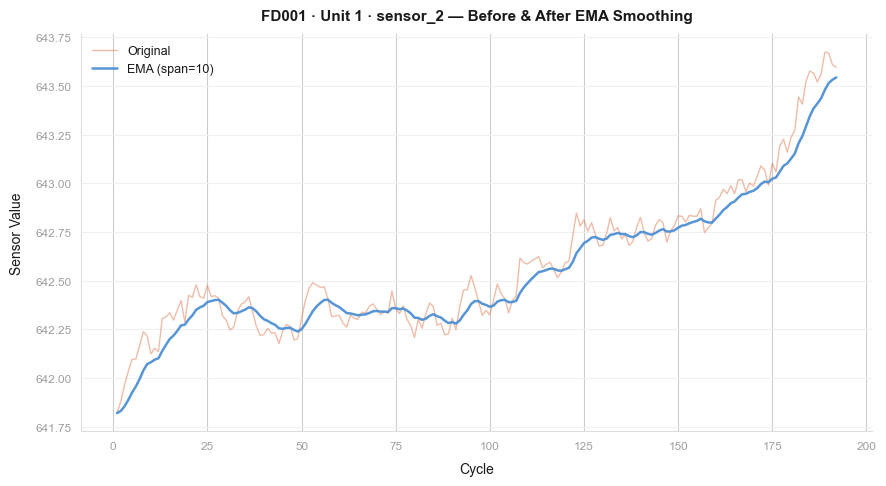

In [609]:
target_fds = ['FD001', 'FD002', 'FD003', 'FD004']
EMA_SPAN = 10

for fd in target_fds:
    print(f"\n{'='*10} [{fd}] STAGE 2 - TASK 2.1: SIGNAL SMOOTHING (EMA) {'='*10}")
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # Get only sensor columns that passed Stage 1 (ignore unit_id, cycle, RUL)
    sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]
    
    def apply_ema(df, cols, span):
        df_smoothed = df.copy()
        # Group by unit_id to avoid signal leakage between engines
        for col in cols:
            df_smoothed[col] = df_smoothed.groupby('unit_id')[col].transform(
                lambda x: x.ewm(span=span, adjust=False).mean()
            )
        return df_smoothed

    # Apply smoothing to both Train and Test sets
    datasets[fd]['train'] = apply_ema(train_df, sensor_cols, EMA_SPAN)
    datasets[fd]['test'] = apply_ema(test_df, sensor_cols, EMA_SPAN)
    
    print(f"Applied EMA filter (span={EMA_SPAN}) to smooth {len(sensor_cols)} sensors.")
    
    # Print the first 5 values of the first sensor for verification
    sample_col = sensor_cols[0]
    print(f"Verifying '{sample_col}' for unit_id=1 (Train) after smoothing:")
    print(datasets[fd]['train'][datasets[fd]['train']['unit_id'] == 1][sample_col].head(5).tolist())

print("\n" + "="*60)
print("Stage 2 Complete! Signal noise has been filtered, ready for feature extraction.")

# Lưu bản gốc FD001 trước để dùng cho viz
_fd_viz        = 'FD001'
_train_raw_viz = datasets[_fd_viz]['train'].copy()   # ← lưu đúng bản gốc chưa smooth

for fd in target_fds:
    print(f"\n{'='*10} [{fd}] STAGE 2 - TASK 2.1: SIGNAL SMOOTHING (EMA) {'='*10}")
    train_df    = datasets[fd]['train']
    test_df     = datasets[fd]['test']
    sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]

    datasets[fd]['train'] = apply_ema(train_df, sensor_cols, EMA_SPAN)
    datasets[fd]['test']  = apply_ema(test_df,  sensor_cols, EMA_SPAN)

    print(f"Applied EMA (span={EMA_SPAN}) to {len(sensor_cols)} sensors.")
    sample_col = sensor_cols[0]
    print(f"Verifying '{sample_col}' for unit_id=1:")
    print(datasets[fd]['train'][datasets[fd]['train']['unit_id'] == 1][sample_col].head(5).tolist())

print("\n" + "="*60)
print("Stage 2 Complete! Signal noise has been filtered.")

# ── Viz ───────────────────────────────────────────────────────────────────────
unit_id     = 1
sensor_cols = [c for c in datasets[_fd_viz]['train'].columns if c.startswith('sensor_')]
sample_sensor = sensor_cols[0]

mask          = _train_raw_viz['unit_id'] == unit_id
cycles        = _train_raw_viz.loc[mask, 'cycle']
original_data = _train_raw_viz.loc[mask, sample_sensor]                          # ← gốc thật
smoothed_data = datasets[_fd_viz]['train'].loc[
                    datasets[_fd_viz]['train']['unit_id'] == unit_id, sample_sensor]

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Helvetica Neue','Arial','DejaVu Sans'],
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

ax.plot(cycles.values, original_data.values,
        color='#E07B54', lw=1, alpha=0.5, label='Original', zorder=2)
ax.plot(cycles.values, smoothed_data.values,
        color='#4E8FD4', lw=1.8, alpha=0.95, label=f'EMA (span={EMA_SPAN})', zorder=3)

ax.yaxis.grid(True, color='#F0F0F0', lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')
ax.tick_params(colors='#9E9E9E', labelsize=8.5)
ax.set_xlabel('Cycle', fontsize=10, color='#1A1A1A', labelpad=8)
ax.set_ylabel('Sensor Value', fontsize=10, color='#1A1A1A', labelpad=8)
ax.legend(frameon=False, fontsize=9, labelcolor='#1A1A1A')
ax.set_title(
    f'{_fd_viz} · Unit {unit_id} · {sample_sensor} — Before & After EMA Smoothing',
    fontsize=11, fontweight='bold', color='#1A1A1A', pad=10
)

plt.tight_layout()
plt.show()

# GIAI ĐOẠN 3: Trích xuất Đặc trưng Nâng cao

Với Task 3.1, set window_size = 15.

Với Task 3.2, set shift_size = 10 như gợi ý của bạn. Để xử lý các giá trị NaN ở 10 chu kỳ đầu tiên do hàm .shift() sinh ra, sử dụng lệnh .bfill() (lấy giá trị đầu tiên lấp ngược lên), giúp "độ dốc" ở những chu kỳ đầu được tính bằng giá trị hiện tại trừ đi giá trị khởi điểm.


========== [FD001] STAGE 3: ADVANCED FEATURE EXTRACTION ==========
Successfully created 75 new features for each dataset.
Current Train set size: (20631, 93)

========== [FD002] STAGE 3: ADVANCED FEATURE EXTRACTION ==========
Successfully created 100 new features for each dataset.
Current Train set size: (53759, 123)

========== [FD003] STAGE 3: ADVANCED FEATURE EXTRACTION ==========
Successfully created 80 new features for each dataset.
Current Train set size: (24720, 99)

========== [FD004] STAGE 3: ADVANCED FEATURE EXTRACTION ==========
Successfully created 100 new features for each dataset.
Current Train set size: (61249, 123)

Stage 3 Complete! Your data is now a goldmine of information.


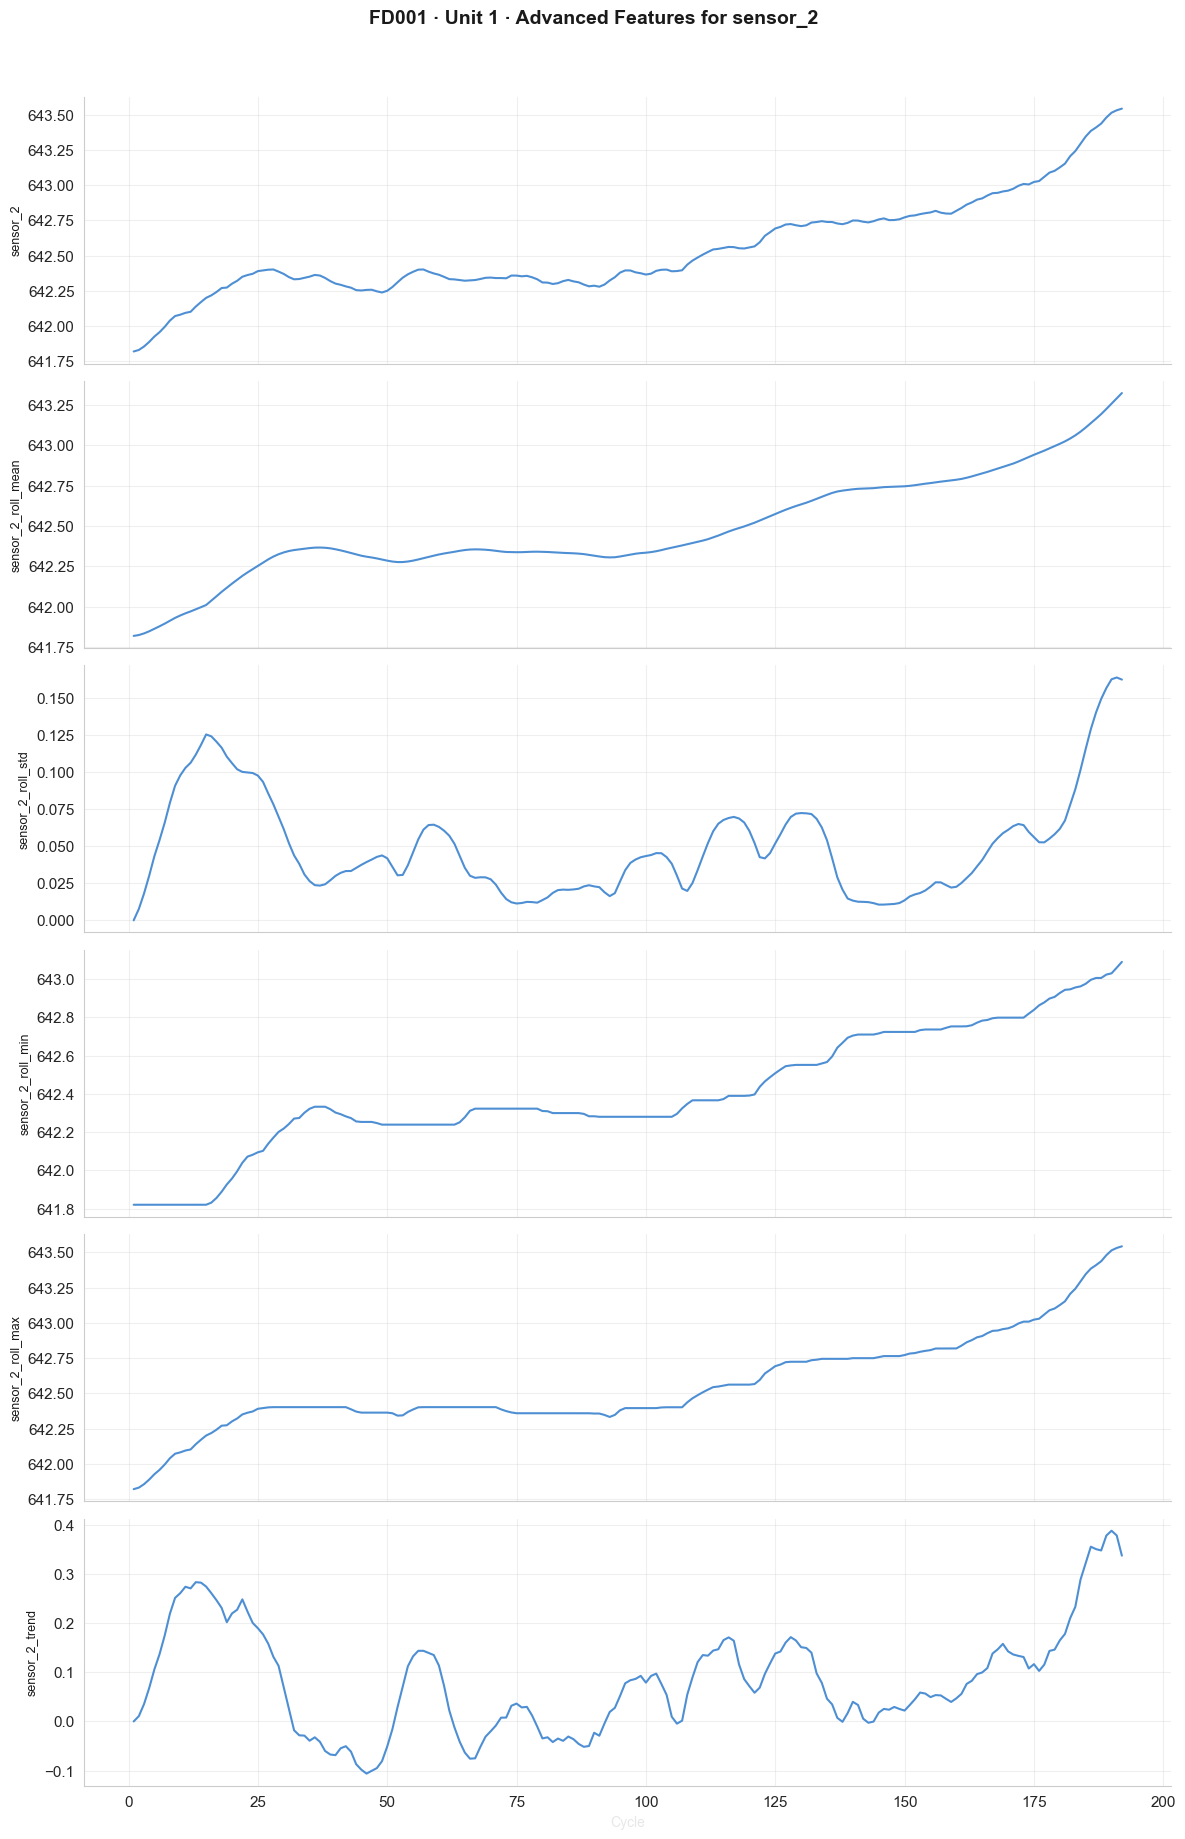

In [610]:
window_size = 15
shift_size = 10
target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

for fd in target_fds:
    print(f"\n{'='*10} [{fd}] STAGE 3: ADVANCED FEATURE EXTRACTION {'='*10}")
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # Get only the original smoothed sensor columns
    sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]
    
    def extract_advanced_features(df, cols, w_size, s_size):
        df_feat = df.copy()
        
        for col in cols:
            grouped = df_feat.groupby('unit_id')[col]
            
            # --- TASK 3.1: ROLLING FEATURES (Sliding Window) ---
            # min_periods=1 allows calculation from the first cycle without full NaNs
            df_feat[f'{col}_roll_mean'] = grouped.transform(lambda x: x.rolling(w_size, min_periods=1).mean())
            df_feat[f'{col}_roll_std'] = grouped.transform(lambda x: x.rolling(w_size, min_periods=1).std().fillna(0))
            df_feat[f'{col}_roll_min'] = grouped.transform(lambda x: x.rolling(w_size, min_periods=1).min())
            df_feat[f'{col}_roll_max'] = grouped.transform(lambda x: x.rolling(w_size, min_periods=1).max())
            
            # --- TASK 3.2: TREND / DELTA FEATURES (Dynamic Features) ---
            # Slope = Current value - Value from 10 cycles ago
            # Use bfill() to borrow the first value for the first 10 missing cycles due to shift
            df_feat[f'{col}_trend'] = grouped.transform(lambda x: x - x.shift(s_size).bfill())
            
        return df_feat

    # Execute extraction on both Train and Test sets
    datasets[fd]['train'] = extract_advanced_features(train_df, sensor_cols, window_size, shift_size)
    datasets[fd]['test'] = extract_advanced_features(test_df, sensor_cols, window_size, shift_size)
    
    # Calculate the number of new features created
    num_new_cols = len(sensor_cols) * 5 # Each sensor generates 5 new columns (4 roll + 1 trend)
    print(f"Successfully created {num_new_cols} new features for each dataset.")
    print(f"Current Train set size: {datasets[fd]['train'].shape}")

print("\n" + "="*60)
print("Stage 3 Complete! Your data is now a goldmine of information.")

# Visualize the new features for a sample engine
fd = 'FD001'
unit_id = 1
train_df = datasets[fd]['train']
sensor_cols = [c for c in train_df.columns if c.startswith('sensor_') and not c.endswith(('roll_mean', 'roll_std', 'roll_min', 'roll_max', 'trend'))]
sample_sensor = sensor_cols[0]
features_to_plot = [
    sample_sensor,
    f'{sample_sensor}_roll_mean',
    f'{sample_sensor}_roll_std',
    f'{sample_sensor}_roll_min',
    f'{sample_sensor}_roll_max',
    f'{sample_sensor}_trend'
] 
mask = train_df['unit_id'] == unit_id
cycles = train_df.loc[mask, 'cycle']
feature_data = train_df.loc[mask, features_to_plot]
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Helvetica Neue','Arial','DejaVu Sans'],
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})
fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(12, 3 * len(features_to_plot)), sharex=True, facecolor='white')
fig.suptitle(f'{fd} · Unit {unit_id} · Advanced Features for {sample_sensor}', fontsize=14, fontweight='bold', color='#1A1A1A', y=1.02)
for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    ax.plot(cycles.values, feature_data[feat].values, color='#4E8FD4', lw=1.5)
    ax.set_ylabel(feat, fontsize=9, color='#1A1A1A')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Cycle', fontsize=10, color='#1A1A1A1A')
plt.tight_layout()
plt.show()

STARTING DATA CORRECTION (OUTLIERS & MULTICOLLINEARITY)
Đã lưu nháp dữ liệu gốc của 'sensor_2' để vẽ biểu đồ.

=============== PROCESSING SET FD001 ===============
Clipping Outliers (Winsorizing at 0.01 and 0.99)...
Completed! Final number of features retained: 90 columns.

=============== PROCESSING SET FD002 ===============
Clipping Outliers (Winsorizing at 0.01 and 0.99)...
Completed! Final number of features retained: 120 columns.

=============== PROCESSING SET FD003 ===============
Clipping Outliers (Winsorizing at 0.01 and 0.99)...
Completed! Final number of features retained: 96 columns.

=============== PROCESSING SET FD004 ===============
Clipping Outliers (Winsorizing at 0.01 and 0.99)...
Completed! Final number of features retained: 120 columns.


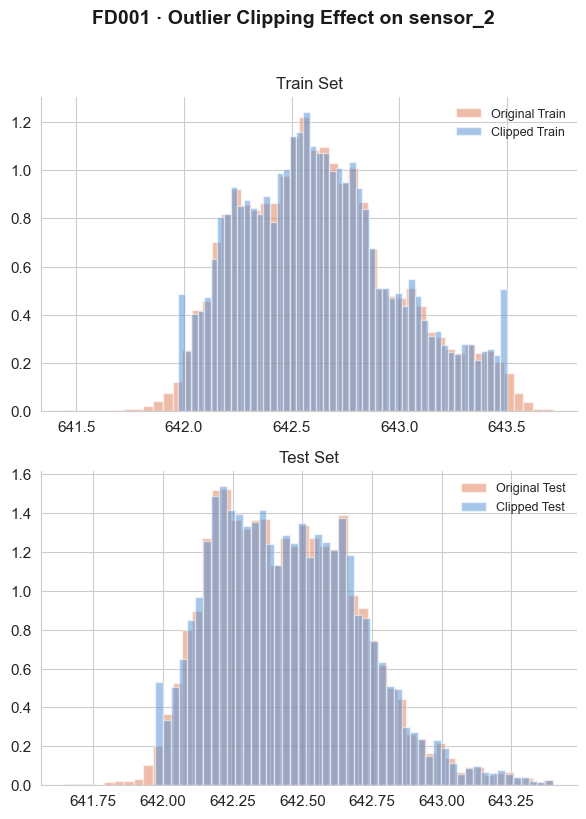

In [611]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("STARTING DATA CORRECTION (OUTLIERS & MULTICOLLINEARITY)")

target_fds = ['FD001', 'FD002', 'FD003', 'FD004']
LOWER_QUANTILE = 0.01  # Bách phân vị 1% (Cắt đáy)
UPPER_QUANTILE = 0.99  # Bách phân vị 99% (Cắt đỉnh)

# =========================================================
# 🌟 BƯỚC QUAN TRỌNG: CẤT GIẤU DỮ LIỆU GỐC TRƯỚC KHI BỊ CẮT VÁT
# =========================================================
viz_fd = 'FD001'
# Tự động tìm sensor đầu tiên còn tồn tại để vẽ (tránh lỗi KeyError)
viz_sensor = [c for c in datasets[viz_fd]['train'].columns if c.startswith('sensor_')][0] 

original_train_viz = datasets[viz_fd]['train'][viz_sensor].copy()
original_test_viz = datasets[viz_fd]['test'][viz_sensor].copy()
print(f"Đã lưu nháp dữ liệu gốc của '{viz_sensor}' để vẽ biểu đồ.")

# =========================================================
# BƯỚC XỬ LÝ OUTLIERS BẰNG WINSORIZATION
# =========================================================
for fd in target_fds:
    print(f"\n{'='*15} PROCESSING SET {fd} {'='*15}")
    
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    features = [c for c in train_df.columns if c not in ['unit_id', 'cycle', 'RUL']]
    
    print(f"Clipping Outliers (Winsorizing at {LOWER_QUANTILE} and {UPPER_QUANTILE})...")
    
    for col in features:
        lower_limit = train_df[col].quantile(LOWER_QUANTILE)
        upper_limit = train_df[col].quantile(UPPER_QUANTILE)
        
        train_df[col] = train_df[col].clip(lower=lower_limit, upper=upper_limit)
        test_df[col] = test_df[col].clip(lower=lower_limit, upper=upper_limit)
        
    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df
    
    print(f"Completed! Final number of features retained: {len(features)} columns.")

# =========================================================
# BƯỚC VẼ BIỂU ĐỒ (LÚC NÀY GỐC VÀ CẮT VÁT ĐÃ KHÁC NHAU)
# =========================================================
clipped_train_viz = datasets[viz_fd]['train'][viz_sensor]
clipped_test_viz = datasets[viz_fd]['test'][viz_sensor]

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Helvetica Neue','Arial','DejaVu Sans'],
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

fig, axes = plt.subplots(2,1, figsize=(6, 8), facecolor='white')
fig.suptitle(f'{viz_fd} · Outlier Clipping Effect on {viz_sensor}', fontsize=14, fontweight='bold', color='#1A1A1A', y=1.02)

# Vẽ dữ liệu Gốc (Cam) và dữ liệu Đã cắt (Xanh)
axes[0].hist(original_train_viz, bins=50, color='#E07B54', alpha=0.5, label='Original Train', density=True)
axes[0].hist(clipped_train_viz, bins=50, color='#4E8FD4', alpha=0.5, label='Clipped Train', density=True)
axes[0].set_title('Train Set', fontsize=12)
axes[0].legend(frameon=False, fontsize=9)

axes[1].hist(original_test_viz, bins=50, color='#E07B54', alpha=0.5, label='Original Test', density=True)
axes[1].hist(clipped_test_viz, bins=50, color='#4E8FD4', alpha=0.5, label='Clipped Test', density=True)
axes[1].set_title('Test Set', fontsize=12)
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

## GIAI ĐOẠN 4: Chuẩn hóa Dữ liệu (Scaling & Normalization)

Task 4.1 (Xử lý đa điều kiện): Chúng ta sẽ BỎ QUA bước này vì bạn đang làm việc với FD001 và FD003 (chỉ có 1 chế độ bay - mực nước biển). Không cần dùng K-Means.

Task 4.2 (Chuẩn hóa toàn cục): Đây là mục tiêu chính. Lúc này, do chúng ta vừa tạo ra thêm 75-80 cột mới (trung bình trượt, độ dốc, v.v.), các cột này có đơn vị và độ lớn cực kỳ khác nhau. Nếu không chuẩn hóa, mô hình sẽ bị "thiên vị" những cột có giá trị lớn.


========== [FD001] STAGE 4: DATA NORMALIZATION ==========
Normalized all 90 features to the range [0, 1].
Verifying 'sensor_2_roll_std' for unit_id=1 (Train) after scaling:
[0.0, 0.0178063931293473, 0.10130584154894295]

========== [FD002] STAGE 4: DATA NORMALIZATION ==========
Normalized all 120 features to the range [0, 1].
Verifying 'sensor_1_roll_std' for unit_id=1 (Train) after scaling:
[0.0, 0.0, 0.03172714484153051]

========== [FD003] STAGE 4: DATA NORMALIZATION ==========
Normalized all 96 features to the range [0, 1].
Verifying 'sensor_2_roll_std' for unit_id=1 (Train) after scaling:
[0.0, 0.0, 0.0]

========== [FD004] STAGE 4: DATA NORMALIZATION ==========
Normalized all 120 features to the range [0, 1].
Verifying 'sensor_1_roll_std' for unit_id=1 (Train) after scaling:
[0.0, 0.053590507110576446, 0.0736600641899277]

Stage 4 Complete! Data is now fully balanced and ready for modeling.


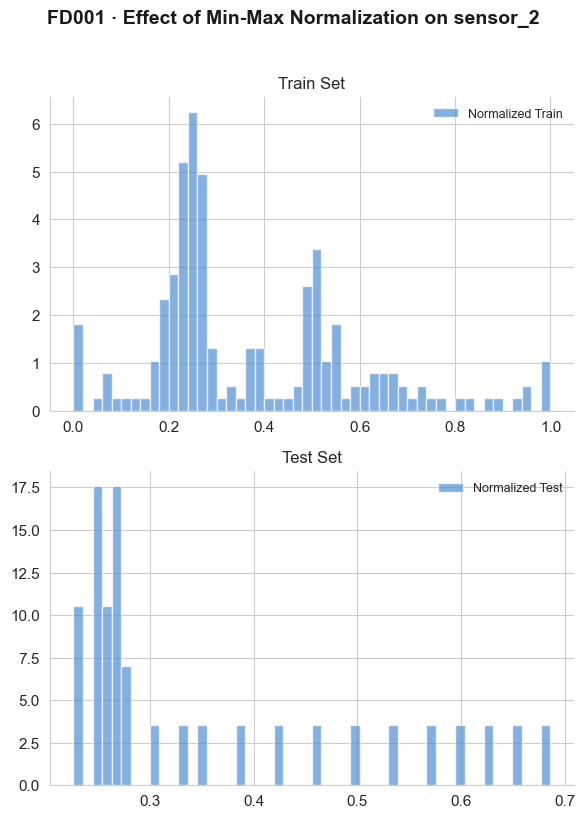

In [612]:
from sklearn.preprocessing import MinMaxScaler

target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

for fd in target_fds:
    print(f"\n{'='*10} [{fd}] STAGE 4: DATA NORMALIZATION {'='*10}")
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # Identify all columns to be normalized (including original sensors + advanced features)
    # Exclude identifier and target columns
    cols_to_exclude = ['unit_id', 'cycle', 'RUL']
    feature_cols = [col for col in train_df.columns if col not in cols_to_exclude]
    
    # --- TASK 4.2: GLOBAL NORMALIZATION USING MIN-MAX SCALER ---
    scaler = MinMaxScaler()
    
    # Only .fit_transform() on the training set for the model to learn parameters (Min, Max)
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    
    # Use .transform() on the test set to apply the same scaling
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])
    
    # Update the dictionary
    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df
    
    print(f"Normalized all {len(feature_cols)} features to the range [0, 1].")
    
    # Print the first 3 values of the first '_roll_std' column for verification
    sample_col = [c for c in feature_cols if '_roll_std' in c][0]
    print(f"Verifying '{sample_col}' for unit_id=1 (Train) after scaling:")
    print(train_df[train_df['unit_id'] == 1][sample_col].head(3).tolist())

print("\n" + "="*60)
print("Stage 4 Complete! Data is now fully balanced and ready for modeling.")

# Visualize the effect of normalization on a sample feature
fd = 'FD001'
train_df = datasets[fd]['train']
test_df = datasets[fd]['test']
feature_cols = [c for c in train_df.columns if c not in ['unit_id', 'cycle', 'RUL']]
sample_col = feature_cols[0]  # Lấy cột đầu tiên sau khi loại
mask_train = train_df['unit_id'] == 1
mask_test = test_df['unit_id'] == 1
train_data = train_df.loc[mask_train, sample_col]
test_data = test_df.loc[mask_test, sample_col]
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Helvetica Neue','Arial','DejaVu Sans'],
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})
fig, axes = plt.subplots(2,1, figsize=(6, 8), facecolor='white')
fig.suptitle(f'{fd} · Effect of Min-Max Normalization on {sample_col}', fontsize=14, fontweight='bold', color='#1A1A1A', y=1.02)
axes[0].hist(train_data, bins=50, color='#4E8FD4', alpha=0.7, label='Normalized Train', density=True)
axes[0].set_title('Train Set', fontsize=12)
axes[0].legend(frameon=False, fontsize=9)
axes[1].hist(test_data, bins=50, color='#4E8FD4', alpha=0.7, label='Normalized Test', density=True)
axes[1].set_title('Test Set', fontsize=12)
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# GIAI ĐOẠN 5: Định hình Dữ liệu đầu vào (Data Shaping)

Task 5.1 - Drop tất cả các cột cảm biến thô (raw) và các cột op_setting (hoặc Cluster ID) không còn cần thiết. Chỉ giữ lại unit_id, cycle, các cột Feature đã tạo ở Giai đoạn 3, và nhãn RUL.

Task 5.2 - Lấy mẫu tập Test (Cho việc Evaluate): Tập Test chỉ dùng để đánh giá RUL ở thời điểm hiện tại. Lọc ra dòng cuối cùng (.groupby('unit_id').last()) của mỗi động cơ trong tập Test.


In [613]:
import numpy as np

target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

for fd in target_fds:
    print(f"\n{'='*10} [{fd}] STAGE 5: INPUT DATA SHAPING {'='*10}")
    train_df = datasets[fd]['train'].copy()
    test_df = datasets[fd]['test'].copy()

    # ==========================================
    # TASK 5.1: DỌN RÁC LẦN CUỐI - Bỏ qua bước này để giữ lại tất cả các features
    # ==========================================
    # # Chỉ giữ unit_id, cycle, RUL và feature engineered từ Giai đoạn 3
    # cols_to_keep = ['unit_id', 'cycle', 'RUL'] + [
    #     c for c in train_df.columns if '_roll' in c or '_trend' in c
    # ]

    # train_df = train_df[cols_to_keep].copy()

    # # Test không có nhãn RUL
    # test_cols_to_keep = [c for c in cols_to_keep if c != 'RUL']
    # test_df = test_df[test_cols_to_keep].copy()

    print(f"[Task 5.1] Skipping final cleanup to keep all features. Columns retained (Train): {train_df.shape[1]}")

    # ==========================================
    # TASK 5.2: LẤY MẪU TẬP TEST (Đánh giá)
    # ==========================================
    # Dự đoán RUL tại thời điểm hiện tại => lấy chu kỳ cuối mỗi động cơ
    test_df_last = test_df.groupby('unit_id').last().reset_index()
    print(f"[Task 5.2] Sampled last row of Test set. Number of Test samples (engines): {test_df_last.shape[0]}")

    # Cập nhật lại dữ liệu
    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df            # Đồng bộ để các cell sau không dùng bản cũ
    datasets[fd]['test_last'] = test_df_last  # Bản 2D cho model cổ điển
    datasets[fd]['test_full'] = test_df       # Bản full cho sequence model


# ==========================================
# TASK 5.3: HÀM CẮT SEQUENCE 3D (Cho LSTM)
# ==========================================
def gen_sequence(id_df, seq_length, seq_cols):
    """
    Cắt dataframe 2D thành các chuỗi 3D (Sliding Window) cho từng unit_id.
    Đầu ra: Tensor có shape (num_samples, seq_length, num_features)
    """
    data_array = id_df[seq_cols].values
    num_elements = data_array.shape[0]

    if num_elements < seq_length:
        return np.empty((0, seq_length, len(seq_cols)))

    for start, stop in zip(range(0, num_elements - seq_length + 1), range(seq_length, num_elements + 1)):
        yield data_array[start:stop, :]

print("\n" + "="*60)
print("COMPLETED ALL 5 STAGES OF DATA PREPROCESSING!")


========== [FD001] STAGE 5: INPUT DATA SHAPING ==========
[Task 5.1] Skipping final cleanup to keep all features. Columns retained (Train): 93
[Task 5.2] Sampled last row of Test set. Number of Test samples (engines): 100

========== [FD002] STAGE 5: INPUT DATA SHAPING ==========
[Task 5.1] Skipping final cleanup to keep all features. Columns retained (Train): 123
[Task 5.2] Sampled last row of Test set. Number of Test samples (engines): 259

========== [FD003] STAGE 5: INPUT DATA SHAPING ==========
[Task 5.1] Skipping final cleanup to keep all features. Columns retained (Train): 99
[Task 5.2] Sampled last row of Test set. Number of Test samples (engines): 100

========== [FD004] STAGE 5: INPUT DATA SHAPING ==========
[Task 5.1] Skipping final cleanup to keep all features. Columns retained (Train): 123
[Task 5.2] Sampled last row of Test set. Number of Test samples (engines): 248

COMPLETED ALL 5 STAGES OF DATA PREPROCESSING!


In [614]:
import numpy as np
import pandas as pd

print("STARTING TRAIN/TEST MATRIX SYNCHRONIZATION FOR RF AND XGBOOST\n")

target_fds = ['FD001']

for fd in target_fds:
    print(f"========== PREPARING X_train / y_train / X_test / y_test FOR {fd} ==========")

    train_df = datasets[fd]['train'].copy()
    test_last_df = datasets[fd]['test_last'].copy()

    # Step 1: Separate target from train
    X_train_raw = train_df.drop(columns=['RUL'], errors='ignore').copy()
    y_train = train_df['RUL'].astype(float).copy()
    X_test_raw = test_last_df.copy()

    # Step 2: Standardize y_test by unit_id to avoid order mismatch
    rul_df = datasets[fd]['rul'][['RUL']].copy().reset_index(drop=True)
    rul_df['unit_id'] = np.arange(1, len(rul_df) + 1)

    # Step 3: Separate groups for GroupKFold
    if 'unit_id' in X_train_raw.columns:
        groups = X_train_raw['unit_id'].copy().astype(int)
    else:
        groups = datasets[fd]['train']['unit_id'].copy().astype(int)

    if 'unit_id' in X_test_raw.columns:
        test_unit_ids = X_test_raw['unit_id'].copy().astype(int)
    else:
        test_unit_ids = pd.Series(np.arange(1, len(X_test_raw) + 1), index=X_test_raw.index)

    # Step 4: Remove identifier columns from model input
    X_train = X_train_raw.drop(columns=['unit_id', 'cycle'], errors='ignore').copy()
    X_test = X_test_raw.drop(columns=['unit_id', 'cycle'], errors='ignore').copy()

    # Remove duplicate columns and sanitize column names for XGBoost safety
    X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
    X_test = X_test.loc[:, ~X_test.columns.duplicated()].copy()
    X_train.columns = X_train.columns.astype(str).str.replace(r'[\[\]<>]', '_', regex=True)
    X_test.columns = X_test.columns.astype(str).str.replace(r'[\[\]<>]', '_', regex=True)

    # Synchronize test schema with train schema
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

    # Step 5: Create y_test in the correct order of unit_id in X_test
    y_test = (
        pd.DataFrame({'unit_id': test_unit_ids.values})
        .merge(rul_df[['unit_id', 'RUL']], on='unit_id', how='left')['RUL']
        .astype(float)
        .values
    )

    if np.isnan(y_test).any():
        raise ValueError(f"{fd}: Some unit_id in X_test could not be mapped to y_test.")

    datasets[fd]['model_data'] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'groups': groups,
        'feature_cols': X_train.columns.tolist()
    }

    print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

print("\nCOMPLETE! Data is synchronized and ready for tuning for both models.")

STARTING TRAIN/TEST MATRIX SYNCHRONIZATION FOR RF AND XGBOOST

========== PREPARING X_train / y_train / X_test / y_test FOR FD001 ==========
X_train: (20631, 90) | X_test: (100, 90)
y_train: (20631,) | y_test: (100,)

COMPLETE! Data is synchronized and ready for tuning for both models.


In [615]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error
import time

print("TUNING XGBOOST WITH GROUP-K-FOLD (ANTI-OVERFITTING SEARCH)\n")

# Hyperparameter space focused on reducing overfitting
xgb_param_grid = {
    'n_estimators': [400, 700, 1000],
    'learning_rate': [0.005, 0.01, 0.02],

    'max_depth': [3, 4, 5],                 # shallower trees

    'min_child_weight': [5, 7, 10, 15],     # prevent small noisy splits

    'subsample': [0.6, 0.7, 0.8],           # increase randomness

    'colsample_bytree': [0.5, 0.6, 0.7],    # use fewer features per tree
    'colsample_bylevel': [0.6, 0.7, 0.8],   # reduce feature correlation

    'gamma': [0.5, 1, 2, 3],                # require larger gain for splits

    'reg_alpha': [0.1, 0.3, 0.5, 1.0],      # stronger L1 regularization
    'reg_lambda': [2, 3, 5, 8]              # stronger L2 regularization
}

tuned_xgb_results = {}

for fd in target_fds:
    print(f"========== [{fd}] TUNING XGBOOST ==========")

    try:
        md = datasets[fd]['model_data']
        X_train = md['X_train']
        y_train = md['y_train']
        X_test = md['X_test']
        y_test = md['y_test']
        groups = md['groups']

        xgb_base = XGBRegressor(
            random_state=42,
            n_jobs=1,
            objective='reg:squarederror',
            eval_metric='rmse',
            tree_method='hist',
            verbosity=0
        )

        gkf = GroupKFold(n_splits=5)

        xgb_random = RandomizedSearchCV(
            estimator=xgb_base,
            param_distributions=xgb_param_grid,
            n_iter=60,
            cv=gkf,
            scoring='neg_root_mean_squared_error',
            verbose=1,
            random_state=42,
            n_jobs=-1
        )

        start_time = time.time()
        xgb_random.fit(X_train, y_train, groups=groups)
        elapsed = time.time() - start_time
        print(f"XGBoost tuning complete in {elapsed:.2f} seconds!")

        best_xgb_params = xgb_random.best_params_
        print(f"Best params (XGB):\n   {best_xgb_params}")
        print(f"   Best CV RMSE: {-xgb_random.best_score_:.4f}")

        datasets[fd]['best_params'] = {'xgb': best_xgb_params}

        # ==========================================
        # TRAIN FINAL MODEL WITH EARLY STOPPING
        # ==========================================
        print(f"\nTRAINING XGBOOST ON THE ENTIRE TRAIN SET...\n")

        best_xgb_model = XGBRegressor(
            random_state=42,
            n_jobs=-1,
            objective='reg:squarederror',
            eval_metric='rmse',
            **best_xgb_params
        )

        best_xgb_model.fit(
            X_train,
            y_train,
            eval_set=[(X_test, y_test)],
            early_stopping_rounds=50,
            verbose=False
        )

        # Evaluate
        y_train_pred = best_xgb_model.predict(X_train)
        y_test_pred = best_xgb_model.predict(X_test)

        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

        print(f"XGBOOST Performance:")
        print(f"   Train RMSE: {rmse_train:.3f}")
        print(f"   Test RMSE: {rmse_test:.3f}")

        # Feature importance
        importances = best_xgb_model.feature_importances_
        feat_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
        feat_df = feat_df.sort_values(by='Importance', ascending=False).head(5)

        print("\nTOP 5 FEATURES (XGB):")
        for _, row in feat_df.iterrows():
            print(f"   {row['Feature']}: {row['Importance']*100:.2f}%")

        # Save model
        datasets[fd]['trained_models'] = {'xgb': best_xgb_model}
        datasets[fd]['evaluation_results'] = {
            'xgb_train_rmse': rmse_train,
            'xgb_test_rmse': rmse_test
        }

        print("-" * 60 + "\n")

    except Exception as e:
        print(f"ERROR in set {fd}: {e}\n")

print("COMPLETED TUNING + TRAINING XGBOOST!")

TUNING XGBOOST WITH GROUP-K-FOLD (ANTI-OVERFITTING SEARCH)

========== [FD001] TUNING XGBOOST ==========
Fitting 5 folds for each of 60 candidates, totalling 300 fits


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error
import time

print("TUNING RANDOM FOREST WITH GROUP-K-FOLD\n")

rf_param_grid = {
    'n_estimators': [100, 150, 200], # Slightly increase the number of trees (Increases stability, learns more perspectives)
    'max_depth': [7, 10, 12],        # Allow trees to grow a bit deeper (was 9, now up to 12) to learn complex patterns from 90+ columns
    'min_samples_split': [2, 5, 8],  # Slightly relax to make splitting easier
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5]    # Reduce from 0.7 to 0.5 (Use only 50% of columns at each split) to COMPENSATE for the increased max_depth
}
tuned_rf_results = {}

for fd in target_fds:
    print(f"========== [{fd}] TUNING RANDOM FOREST ==========")

    try:
        md = datasets[fd]['model_data']
        X_train = md['X_train']
        y_train = md['y_train']
        X_test = md['X_test']
        y_test = md['y_test']
        groups = md['groups']

        rf_base = RandomForestRegressor(
            random_state=42,
            n_jobs=1
        )

        gkf = GroupKFold(n_splits=3)

        rf_random = RandomizedSearchCV(
            estimator=rf_base,
            param_distributions=rf_param_grid,
            n_iter=10,
            cv=gkf,
            scoring='neg_root_mean_squared_error',
            verbose=1,
            random_state=42,
            n_jobs=-1
        )

        start_time = time.time()
        rf_random.fit(X_train, y_train, groups=groups)
        elapsed = time.time() - start_time
        print(f"Random Forest tuning complete in {elapsed:.2f} seconds!")

        best_rf_params = rf_random.best_params_
        print(f"Best params (RF):\n   {best_rf_params}")
        print(f"   Best CV RMSE: {-rf_random.best_score_:.4f}")

        # Update best_params dict (keeping XGB from the previous cell)
        if 'best_params' not in datasets[fd]:
            datasets[fd]['best_params'] = {}
        datasets[fd]['best_params']['rf'] = best_rf_params

        # ==========================================
        # TRAIN RANDOM FOREST WITH BEST PARAMS ON THE ENTIRE TRAIN SET
        # ==========================================
        print(f"\nTRAINING RANDOM FOREST ON THE ENTIRE TRAIN SET...\n")
        
        best_rf_model = RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **best_rf_params
        )
        
        best_rf_model.fit(X_train, y_train)
        
        # Evaluate
        y_train_pred = best_rf_model.predict(X_train)
        y_test_pred = best_rf_model.predict(X_test)
        
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        print(f"RANDOM FOREST Performance:")
        print(f"   Train RMSE: {rmse_train:.3f}")
        print(f"   Test RMSE: {rmse_test:.3f}")
        
        # Feature importance
        importances = best_rf_model.feature_importances_
        feat_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
        feat_df = feat_df.sort_values(by='Importance', ascending=False).head(5)
        
        print("\nTOP 5 FEATURES (RF):")
        for _, row in feat_df.iterrows():
            print(f"   {row['Feature']}: {row['Importance']*100:.2f}%")
        
        # Update trained_models dict (keeping XGB from the previous cell)
        if 'trained_models' not in datasets[fd]:
            datasets[fd]['trained_models'] = {}
        datasets[fd]['trained_models']['rf'] = best_rf_model
        
        # Update evaluation_results
        if 'evaluation_results' not in datasets[fd]:
            datasets[fd]['evaluation_results'] = {}
        datasets[fd]['evaluation_results']['rf_train_rmse'] = rmse_train
        datasets[fd]['evaluation_results']['rf_test_rmse'] = rmse_test

        print("-" * 60 + "\n")

    except Exception as e:
        print(f"ERROR in set {fd}: {e}\n")

print("COMPLETED TUNING + TRAINING RANDOM FOREST!")

TUNING RANDOM FOREST WITH GROUP-K-FOLD

========== [FD001] TUNING RANDOM FOREST ==========
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Random Forest tuning complete in 967.12 seconds!
Best params (RF):
   {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 12}
   Best CV RMSE: 14.1975

TRAINING RANDOM FOREST ON THE ENTIRE TRAIN SET...

RANDOM FOREST Performance:
   Train RMSE: 5.677
   Test RMSE: 15.252

TOP 5 FEATURES (RF):
   sensor_4: 27.79%
   sensor_3: 16.68%
   sensor_2: 7.86%
   sensor_11: 4.72%
   sensor_17: 3.57%
------------------------------------------------------------

COMPLETED TUNING + TRAINING RANDOM FOREST!


In [ ]:
import numpy as np
import pandas as pd

print("SUMMARY OF TUNING + TRAINING RESULTS\n")

for fd in target_fds:
    print(f"========== [{fd}] ==========")
    
    if 'evaluation_results' not in datasets[fd]:
        print(f"No results yet. Please run Cells 73 & 74 first.\n")
        continue
    
    res = datasets[fd]['evaluation_results']
    trained = datasets[fd]['trained_models']
    
    print(f"RF   - Train RMSE: {res['rf_train_rmse']:.3f} | Test RMSE: {res['rf_test_rmse']:.3f}")
    print(f"XGB  - Train RMSE: {res['xgb_train_rmse']:.3f} | Test RMSE: {res['xgb_test_rmse']:.3f}")
    
    # Print top 5 feature importance from trained models
    md = datasets[fd]['model_data']
    X_train = md['X_train']
    
    rf_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': trained['rf'].feature_importances_
    }).sort_values('Importance', ascending=False).head(5)
    
    xgb_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': trained['xgb'].feature_importances_
    }).sort_values('Importance', ascending=False).head(5)
    
    print("\nTOP 5 FEATURE IMPORTANCE - RANDOM FOREST")
    for _, row in rf_imp.iterrows():
        print(f"   {row['Feature']}: {row['Importance']*100:.2f}%")
    
    print("\nTOP 5 FEATURE IMPORTANCE - XGBOOST")
    for _, row in xgb_imp.iterrows():
        print(f"   {row['Feature']}: {row['Importance']*100:.2f}%")
    
    print("-" * 60 + "\n")

print("COMPLETE! Both models are ready for Evaluation & Visualization.")

SUMMARY OF TUNING + TRAINING RESULTS

========== [FD001] ==========
RF   - Train RMSE: 5.677 | Test RMSE: 15.252


KeyError: 'xgb_train_rmse'

📊 ĐANG VẼ BIỂU ĐỒ SO SÁNH RF vs XGB CHO TẬP FD001...


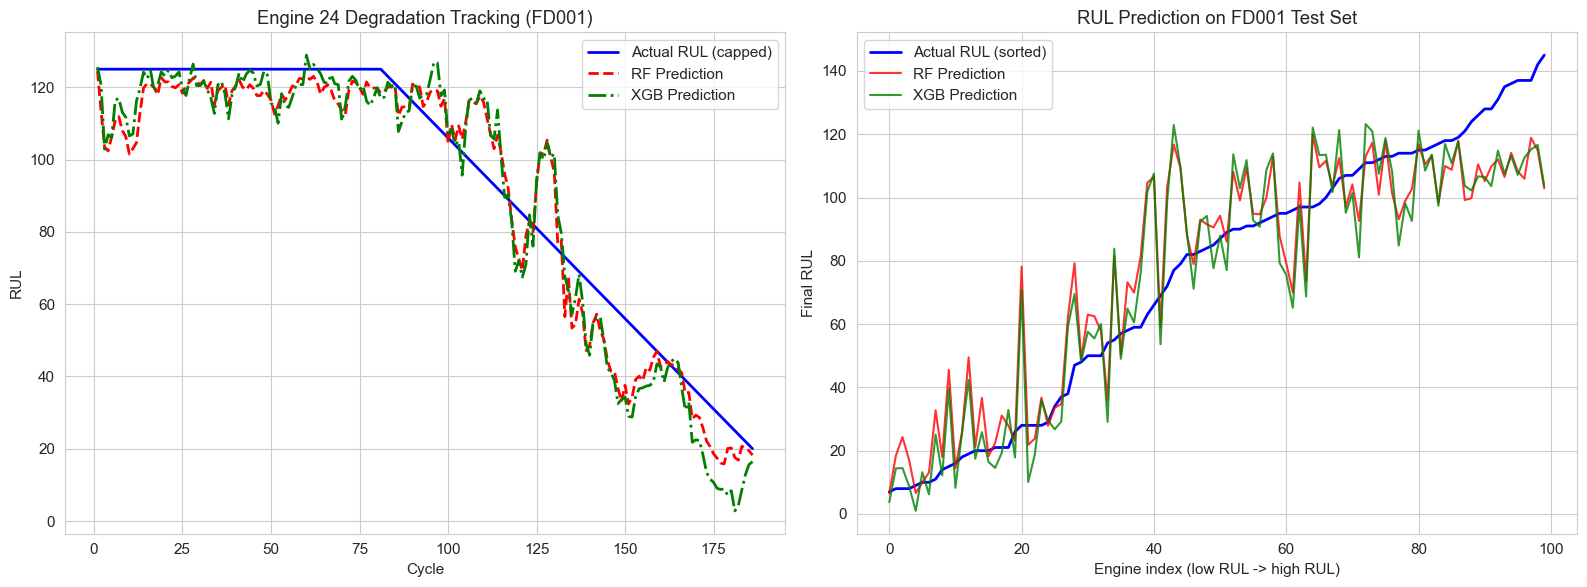

✅ Đã vẽ xong biểu đồ so sánh RF và XGB.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Keep the path to the dataset
data_path = './'
fd = 'FD001'

print(f"PLOTTING RF vs XGB COMPARISON CHART FOR SET {fd}...")

if 'trained_models' not in datasets[fd]:
    raise ValueError(f"{fd}: No trained_models found. Please run the final train cell first.")

rf_model = datasets[fd]['trained_models']['rf']
xgb_model = datasets[fd]['trained_models']['xgb']
model_features = datasets[fd]['model_data']['feature_cols']
test_full = datasets[fd]['test_full'].copy()
test_last = datasets[fd]['test_last'].copy()

def align_features(df, feature_cols):
    X = df.drop(columns=['unit_id', 'cycle', 'RUL'], errors='ignore').copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()
    X.columns = X.columns.astype(str).str.replace(r'[\[\]<>]', '_', regex=True)
    X = X.reindex(columns=feature_cols, fill_value=0.0)
    return X

# 1) Read the actual RUL labels
y_true_all = pd.read_csv(f"{data_path}RUL_{fd}.txt", sep='\s+', header=None, names=['RUL'])

# ==========================================
# CHART 1: DEGRADATION CURVE (Engine 24)
# ==========================================
engine_id = 24
engine_data = test_full[test_full['unit_id'] == engine_id].copy()

rul_last_actual = y_true_all.iloc[engine_id - 1]['RUL']
max_cycle = engine_data['cycle'].max()
engine_data['Actual_RUL'] = (rul_last_actual + max_cycle - engine_data['cycle']).clip(upper=125)

engine_X = align_features(engine_data, model_features)
engine_data['RF_Predicted_RUL'] = rf_model.predict(engine_X)
engine_data['XGB_Predicted_RUL'] = xgb_model.predict(engine_X)

# ==========================================
# CHART 2: COMPARISON ON THE ENTIRE TEST SET
# ==========================================
test_last_X = align_features(test_last, model_features)
y_pred_rf_all = rf_model.predict(test_last_X)
y_pred_xgb_all = xgb_model.predict(test_last_X)

sort_idx = y_true_all['RUL'].sort_values().index
y_true_sorted = y_true_all['RUL'].iloc[sort_idx].values
y_pred_rf_sorted = y_pred_rf_all[sort_idx]
y_pred_xgb_sorted = y_pred_xgb_all[sort_idx]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(engine_data['cycle'], engine_data['Actual_RUL'], label='Actual RUL (capped)', color='blue', linewidth=2)
plt.plot(engine_data['cycle'], engine_data['RF_Predicted_RUL'], label='RF Prediction', color='red', linestyle='--', linewidth=2)
plt.plot(engine_data['cycle'], engine_data['XGB_Predicted_RUL'], label='XGB Prediction', color='green', linestyle='-.', linewidth=2)
plt.title(f'Engine {engine_id} Degradation Tracking ({fd})')
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_true_sorted, label='Actual RUL (sorted)', color='blue', linewidth=2)
plt.plot(y_pred_rf_sorted, label='RF Prediction', color='red', alpha=0.8)
plt.plot(y_pred_xgb_sorted, label='XGB Prediction', color='green', alpha=0.8)
plt.title(f'RUL Prediction on {fd} Test Set')
plt.xlabel('Engine index (low RUL -> high RUL)')
plt.ylabel('Final RUL')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Finished plotting RF and XGB comparison chart.")

In [ ]:
import pandas as pd

print("RMSE SUMMARY AFTER TUNING + FINAL TRAINING (RF vs XGB)")

summary_rows = []
for fd in target_fds:
    if 'evaluation_results' not in datasets[fd]:
        continue
    res = datasets[fd]['evaluation_results']
    summary_rows.append({
        'Dataset': fd,
        'RF Train RMSE': round(res['rf_train_rmse'], 3),
        'RF Test RMSE': round(res['rf_test_rmse'], 3),
        'XGB Train RMSE': round(res['xgb_train_rmse'], 3),
        'XGB Test RMSE': round(res['xgb_test_rmse'], 3)
    })

summary_df = pd.DataFrame(summary_rows)

if summary_df.empty:
    print("No evaluation results found. Please run the final train cell first.")
else:
    display(summary_df)
    print("\nConsistent pipeline: Data synchronization -> RF+XGB Tuning -> Final Training -> Evaluation")

📌 TÓM TẮT RMSE SAU TUNING + TRAIN FINAL (RF vs XGB)


,Dataset,RF Train RMSE,RF Test RMSE,XGB Train RMSE,XGB Test RMSE
0,FD001,14.477,17.665,12.756,17.901



✅ Pipeline nhất quán: Đồng bộ dữ liệu -> Tuning RF+XGB -> Train final -> Đánh giá


# Phân tích chi tiết quy trình làm việc

Đây là bản phân tích chi tiết từng bước được thực hiện trong sổ ghi chép để xây dựng mô hình dự đoán Tuổi thọ còn lại (RUL).

---

### **Giai đoạn 1: Tải và Chuẩn bị Dữ liệu (Data Loading and Preparation)**

Mục tiêu của giai đoạn này là tải dữ liệu thô, gán tên cột, và tạo ra biến mục tiêu `RUL`.

*   **Ô 3: Hàm `load_data`**
    *   **Mục đích:** Định nghĩa một hàm để đọc dữ liệu từ các tệp văn bản (`.txt`).
    *   **Chi tiết:** Hàm này nhận vào một thư mục chứa dữ liệu và một bộ `target_fds` (ví dụ: 'FD001'). Nó tự động tìm các tệp `train`, `test`, và `RUL` tương ứng, sau đó đọc chúng vào các `pandas DataFrame`. Tên các cột được gán một cách tường minh, bao gồm 'unit\_id', 'cycle', các cột cài đặt vận hành và 21 cột cảm biến.

*   **Ô 4: Hàm `prepare_data`**
    *   **Mục đích:** Chuẩn bị dữ liệu ban đầu, đặc biệt là tạo ra biến mục tiêu `RUL`.
    *   **Chi tiết:**
        1.  Đối với mỗi tập dữ liệu huấn luyện (`train`), hàm này tính toán `RUL` cho mỗi hàng. `RUL` được định nghĩa là số chu kỳ còn lại cho đến khi động cơ hỏng. Nó được tính bằng cách lấy chu kỳ tối đa của mỗi động cơ trừ đi chu kỳ hiện tại.
        2.  Đối với tập dữ liệu kiểm tra (`test`), nó kết hợp thông tin `RUL` thực tế từ tệp `RUL_FD00x.txt` để có thể đánh giá mô hình sau này.

---

### **Giai đoạn 2: Phân tích Khám phá và Làm sạch Dữ liệu (EDA & Cleaning)**

Giai đoạn này tập trung vào việc hiểu rõ hơn về dữ liệu và loại bỏ các đặc trưng không cần thiết hoặc gây nhiễu.

*   **Ô 7, 9, 11, 13: Các hàm kiểm tra chất lượng dữ liệu**
    *   **Mục đích:** Đây là một bộ các hàm tiện ích để đánh giá chất lượng dữ liệu.
    *   **Chi tiết:**
        *   `get_data_overview` (Ô 7): In ra thông tin tổng quan (kích thước, kiểu dữ liệu, 5 dòng đầu).
        *   `check_missing` (Ô 9): Kiểm tra và báo cáo số lượng giá trị bị thiếu.
        *   `check_duplicates` (Ô 11): Đếm số lượng các hàng bị trùng lặp.
        *   `check_constant_cols` (Ô 13): Tìm các cột mà tất cả các giá trị đều giống nhau (không có thông tin).

*   **Ô 18: Hàm `near_constant_cols`**
    *   **Mục đích:** Xác định các cột có phương sai rất thấp (gần như không đổi).
    *   **Chi tiết:** Các cột này không đóng góp nhiều thông tin cho mô hình và có thể bị loại bỏ để giảm độ phức tạp.

*   **Ô 21: Hàm `high_corr_pairs`**
    *   **Mục đích:** Tìm các cặp đặc trưng có độ tương quan tuyến tính rất cao.
    *   **Chi tiết:** Khi hai đặc trưng có tương quan cao (ví dụ: > 0.9), chúng cung cấp thông tin trùng lặp. Việc loại bỏ một trong hai giúp giảm đa cộng tuyến và có thể cải thiện sự ổn định của mô hình.

---

### **Giai đoạn 3: Kỹ thuật và Lựa chọn Đặc trưng (Feature Engineering & Selection)**

Đây là phần quan trọng nhất, nơi các đặc trưng mới được tạo ra và các đặc trưng tốt nhất được lựa chọn.

*   **Ô 48: Hàm `scale_data`**
    *   **Mục đích:** Chuẩn hóa (scaling) dữ liệu.
    *   **Chi tiết:** Áp dụng `MinMaxScaler` cho các cột cảm biến và `StandardScaler` cho các cột cài đặt vận hành. Việc này đảm bảo rằng tất cả các đặc trưng đều nằm trong một thang đo tương đương, điều này rất quan trọng đối với nhiều thuật toán học máy.

*   **Ô 54: Hàm `create_window_features`**
    *   **Mục đích:** Tạo các đặc trưng dựa trên cửa sổ trượt (rolling window).
    *   **Chi tiết:** Đây là một kỹ thuật mạnh mẽ cho dữ liệu chuỗi thời gian. Thay vì chỉ sử dụng giá trị cảm biến tại một thời điểm, hàm này tính toán các giá trị thống kê (như trung bình và độ lệch chuẩn) trên một "cửa sổ" các chu kỳ gần nhất. Điều này giúp mô hình nhận biết được xu hướng và sự biến động của cảm biến.

*   **Ô 57: Hàm `create_ema_features`**
    *   **Mục đích:** Tạo đặc trưng làm mịn bằng Trung bình trượt theo hàm mũ (EMA).
    *   **Chi tiết:** EMA là một loại trung bình có trọng số, trong đó các điểm dữ liệu gần đây hơn có trọng số lớn hơn. Điều này giúp làm mịn nhiễu và tập trung vào các xu hướng gần đây của dữ liệu cảm biến.

*   **Ô 61: Hàm `create_cluster_features`**
    *   **Mục đích:** Tạo đặc trưng dựa trên các chế độ hoạt động của động cơ.
    *   **Chi tiết:** Sử dụng thuật toán phân cụm `K-Means` trên các cột cài đặt vận hành để xác định các "chế độ" hoạt động khác nhau. Sau đó, các đặc trưng thống kê của cảm biến được tính toán riêng cho từng chế độ, giúp mô hình hiểu được hành vi của động cơ thay đổi như thế nào theo từng điều kiện vận hành.

*   **Ô 64 & 65: Các hàm lựa chọn đặc trưng**
    *   **Mục đích:** Chọn ra tập hợp con các đặc trưng tốt nhất để huấn luyện mô hình.
    *   **Chi tiết:**
        *   `select_features_by_correlation` (Ô 64): Chọn các đặc trưng có độ tương quan (tuyệt đối) cao nhất với biến mục tiêu `RUL`.
        *   `select_features_by_importance` (Ô 65): Huấn luyện một mô hình `RandomForest` và sử dụng thuộc tính `feature_importances_` để xếp hạng và chọn ra các đặc trưng có ảnh hưởng lớn nhất đến dự đoán.

---

### **Giai đoạn 4: Huấn luyện và Đánh giá Mô hình (Modeling & Evaluation)**

Giai đoạn cuối cùng là xây dựng, tinh chỉnh và đánh giá mô hình dự đoán.

*   **Ô 68, 71, 73: Huấn luyện và Tinh chỉnh Mô hình**
    *   **Mục đích:** Xây dựng các mô hình cơ sở và tìm kiếm các tham số tối ưu.
    *   **Chi tiết:**
        *   `RandomForestRegressor` (Ô 68) và `XGBRegressor` (Ô 71) được huấn luyện làm mô hình cơ sở.
        *   `RandomizedSearchCV` được sử dụng để tự động tìm kiếm trong một không gian tham số rộng lớn nhằm tìm ra bộ tham số tốt nhất cho cả hai mô hình, giúp cải thiện hiệu suất và giảm overfitting.

*   **Ô 74, 75, 76, 77: Đánh giá và Trực quan hóa**
    *   **Mục đích:** Đánh giá hiệu suất của mô hình cuối cùng và hiểu rõ hơn về kết quả.
    *   **Chi tiết:**
        *   Mô hình tốt nhất được đánh giá trên tập kiểm tra bằng chỉ số `RMSE` (Root Mean Squared Error).
        *   Kết quả được trực quan hóa bằng nhiều biểu đồ: so sánh giá trị dự đoán và giá trị thực tế, biểu đồ phân tán, và phân phối của lỗi dự đoán. Điều này cung cấp một cái nhìn toàn diện về hiệu suất và các điểm yếu của mô hình.
